# 1. Relative Frequencies
In this notebook, I will follow a similar approach to "Extension or Expansion" by Bonin et al. where I will firstly investigate the relative frequencies of certain words in the corpus. Firstly, I wrote this small block of code to test lemmatized words (I just wanted to make sure that democracy (n.) and democratic (adj.) are treated as semantically separate by code and also in my already-lemmatized corpus).

Here is the link to the article I am referring to: [https://jyx.jyu.fi/jyx/Record/jyx_123456789_108356](https://jyx.jyu.fi/jyx/Record/jyx_123456789_108356).

### Remark on AI use
I just want to be transparent about this! For the most part, I am responsible for writing my own code. However, I did consult / use AI at certain points.
1. While working through this, I wrote a lot of my own plotting code. I then used AI to give me pretty plotting code. I think this is very obvious! Personally, I think this is a fair use of AI, since I already know how to modify plots and I don't want to waste time beautifying my plots or picking out the best aesthetics. I will try my best to make a note above those "pretty plotting" cells about this. Though, it is probably obvious enough!
2. Some troubleshooting: I do miss being back at Harvey Mudd in pre-AI days, when the only way to get help is to consult a friend or do pair-programming with them! I no longer have that privilege; I do my best to troubleshoot things on my own since I enjoy the problem solving procress, but if I'm really at the end of my wits I sometimes ask ChatGPT to help me troubleshoot. Or, I get it to review my code with long-runtimes that I haven't missed anything before I actually run it. I will say though, I will only use it for things that I know or can verify. I would not use it for something that I can't verify with my own coding knowledge, as that is quite sketchy.

In [11]:
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

word = "democratizing"

lemma = lemmatizer.lemmatize(word, pos='v')

print(lemma)

democratize


[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/inqfinity/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/inqfinity/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Here, I have defined a list of `words_to_find`. In the article, Bonin et al. primarily investigate the term "democratic." Though, they investigate it comparatively to the Swedish case. In my case, I am only looking at UK Parliamentary (Hansard) archives. Nevertheless, I thought it wouldn't hurt to also introduce some other aspects to this. Firstly, I have included all three words that are more relevant to my project: democracy, fascism, and crisis. Secondly, I wanted to investigate the case of noun vs. adjective. I'd like to note, though, that I can't think of a good adjective of "crisis" other than "critical." Even if "democratic" is the only word that I can compare my results to, against the results by Bonin et al. I still think it might be worth looking at the overall trends of those other terms.

In [13]:
import pandas as pd
import glob
import ast
import matplotlib.pyplot as plt
import os

words_to_find = ["democratic", "democracy", "undemocratic", "fascist", "fascism", "crisis", "critical"]

input_files = sorted(glob.glob("/Users/inqfinity/mip/hansard_1979-2021/processed_csvs/*_processed.csv"))

output_folder = "/Users/inqfinity/mip/relative_frequency_outputs"
os.makedirs(output_folder, exist_ok=True)

In [14]:
for target_word in words_to_find:

    results = []

    for file in input_files:

        year = int(file.split("/")[-1][:4])

        df = pd.read_csv(file, low_memory=False)
        df = df[df["speech_class"] == "Speech"] #keep just speeches

        total_tokens = 0
        target_count = 0

        for lemmas in df["speech_lemmas_list"].dropna():
            tokens = ast.literal_eval(lemmas)
            total_tokens += len(tokens)
            target_count += tokens.count(target_word)

        relative_frequency = (target_count / total_tokens if total_tokens > 0 else 0) #in case of 0

        results.append({"year": year, "word": target_word, "count": target_count, "total_tokens": total_tokens, "relative_freq": relative_frequency})

    results_df = pd.DataFrame(results) #save csv
    results_df["smoothed_frequency"] = (results_df["relative_freq"].rolling(window=5, center=True, min_periods=1).mean())
    csv_path = f"{output_folder}/{target_word}_relative_freq.csv"
    results_df.to_csv(csv_path, index=False)

    print(f"Saved CSV: {csv_path}")


Saved CSV: /Users/inqfinity/mip/relative_frequency_outputs/democratic_relative_freq.csv
Saved CSV: /Users/inqfinity/mip/relative_frequency_outputs/democracy_relative_freq.csv
Saved CSV: /Users/inqfinity/mip/relative_frequency_outputs/undemocratic_relative_freq.csv
Saved CSV: /Users/inqfinity/mip/relative_frequency_outputs/fascist_relative_freq.csv
Saved CSV: /Users/inqfinity/mip/relative_frequency_outputs/fascism_relative_freq.csv
Saved CSV: /Users/inqfinity/mip/relative_frequency_outputs/crisis_relative_freq.csv
Saved CSV: /Users/inqfinity/mip/relative_frequency_outputs/critical_relative_freq.csv


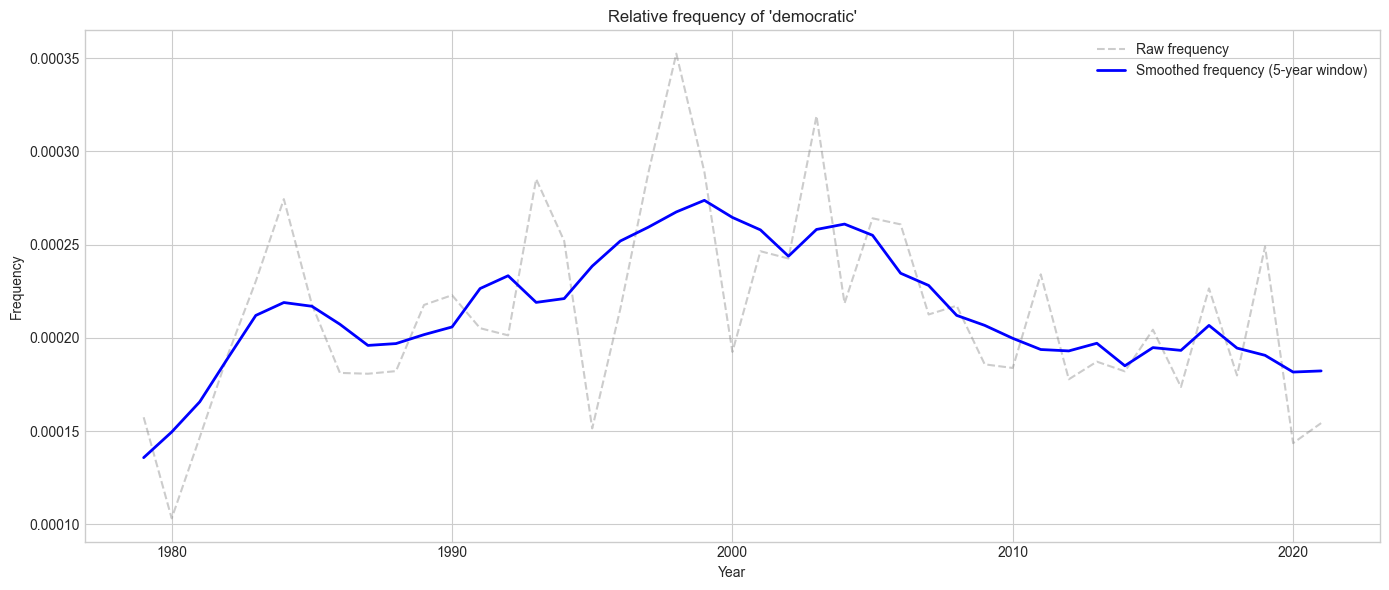

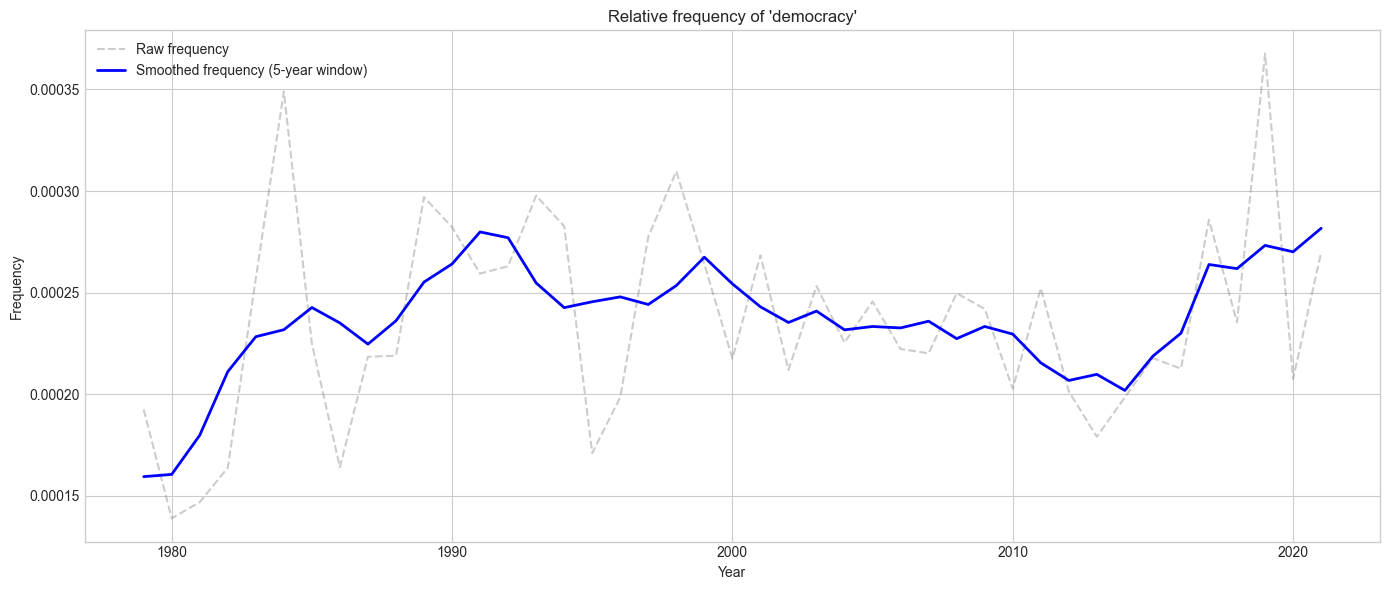

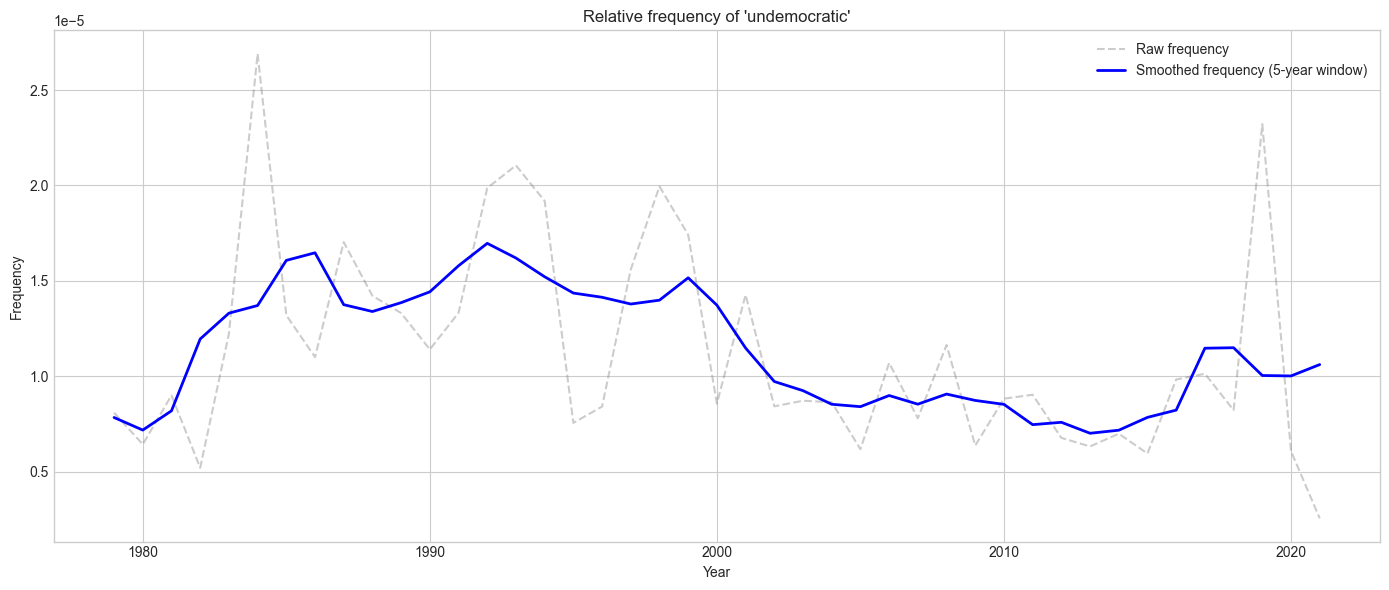

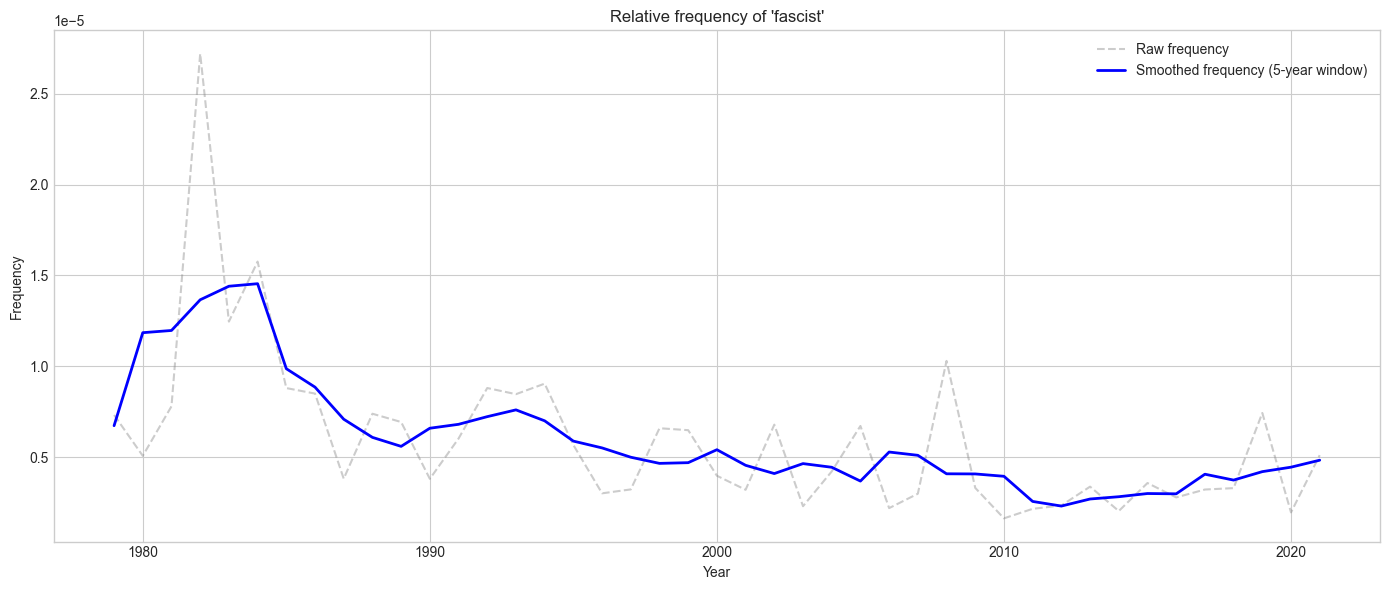

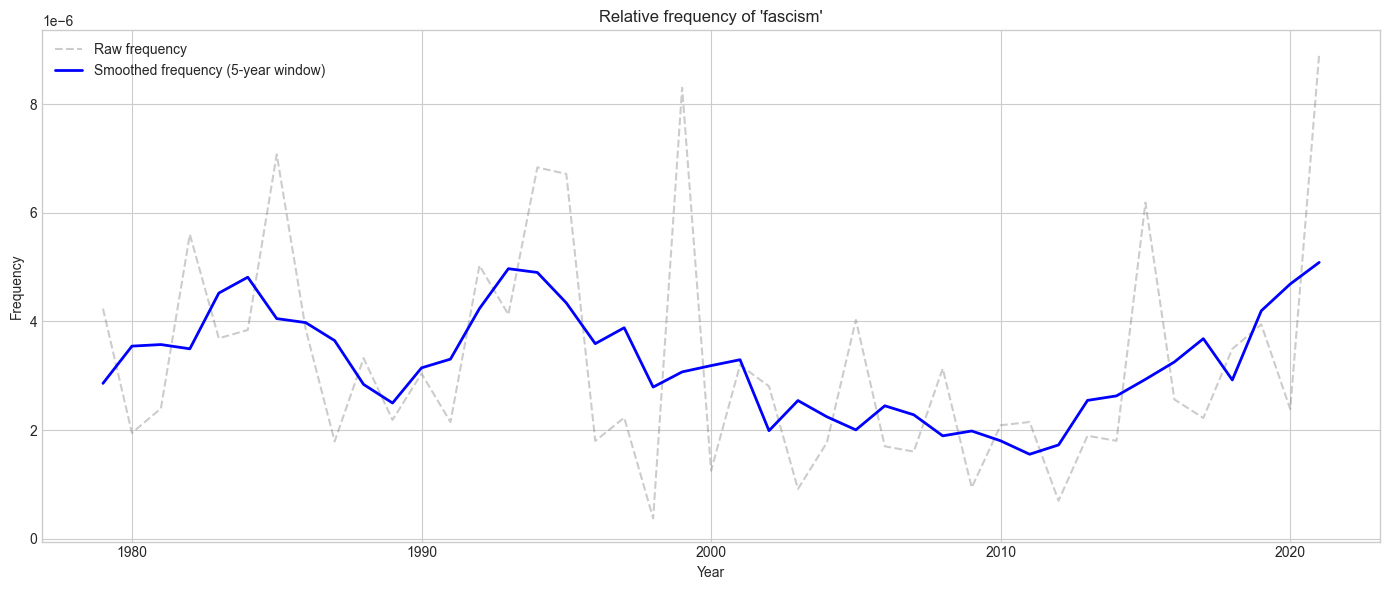

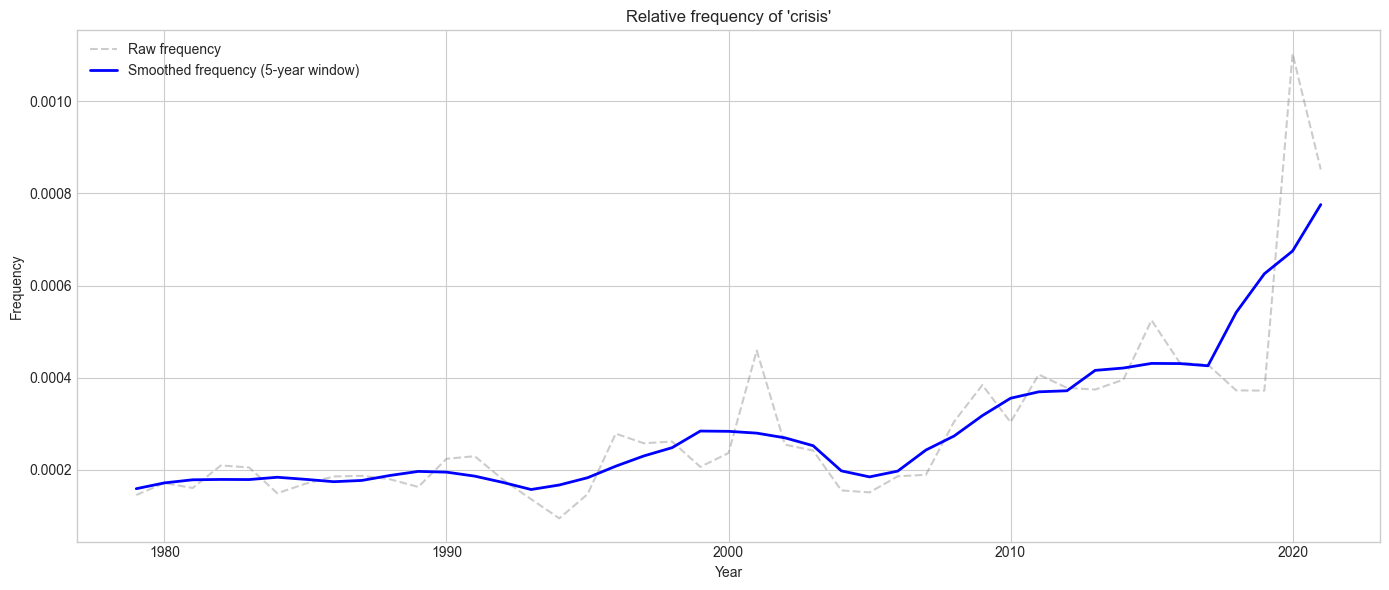

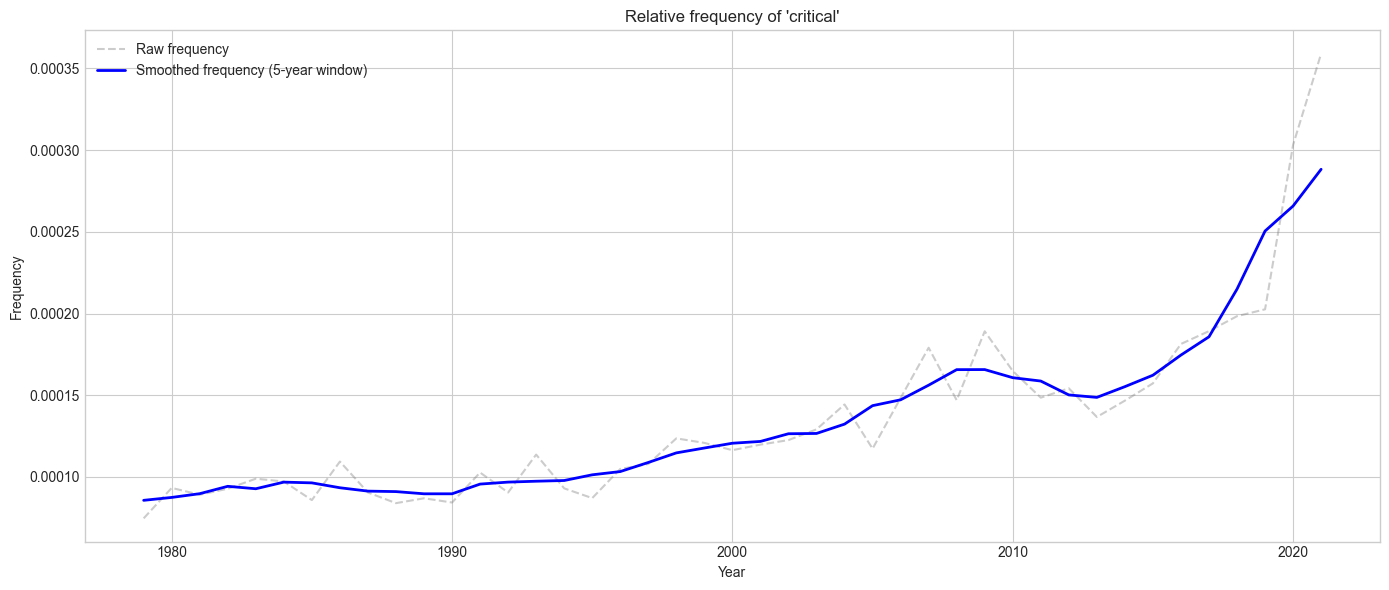

In [15]:
window_size = 5

for target_word in words_to_find:
    
    csv_path = f"/Users/inqfinity/mip/relative_frequency_outputs/{target_word}_relative_freq.csv"
    results_df = pd.read_csv(csv_path)
    
    custom_smooth_col = f"smoothed_{window_size}yr" #make a custom smoothing column
    results_df[custom_smooth_col] = (results_df["relative_freq"].rolling(window=window_size, center=True, min_periods=1).mean())
    
    plt.figure(figsize=(14, 6))
    
    plt.plot(results_df["year"], results_df["relative_freq"], label="Raw frequency", color="gray", alpha=0.4, linestyle="--") #background plotting to compare
    
    plt.plot(results_df["year"], results_df[custom_smooth_col], label=f"Smoothed frequency ({window_size}-year window)", color="blue", linewidth=2)
    
    plt.title(f"Relative frequency of '{target_word}'")
    plt.xlabel("Year")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Make it look nice!
Since we already have raw (congregate) frequencies saved as `.csv` files, plotting them is no problem. I'll have to make a remark that for the nicer-looking plots, I used AI to give me a more "pretty" plotting code by feeding it code from the block above, and asking it to produce code for a nicer plot with `seaborn`. While I already know how to modify plots and apply aesthetic packages, it is simply not worth my time! I am only doing this just in case this needs to be more presentable for a research paper!

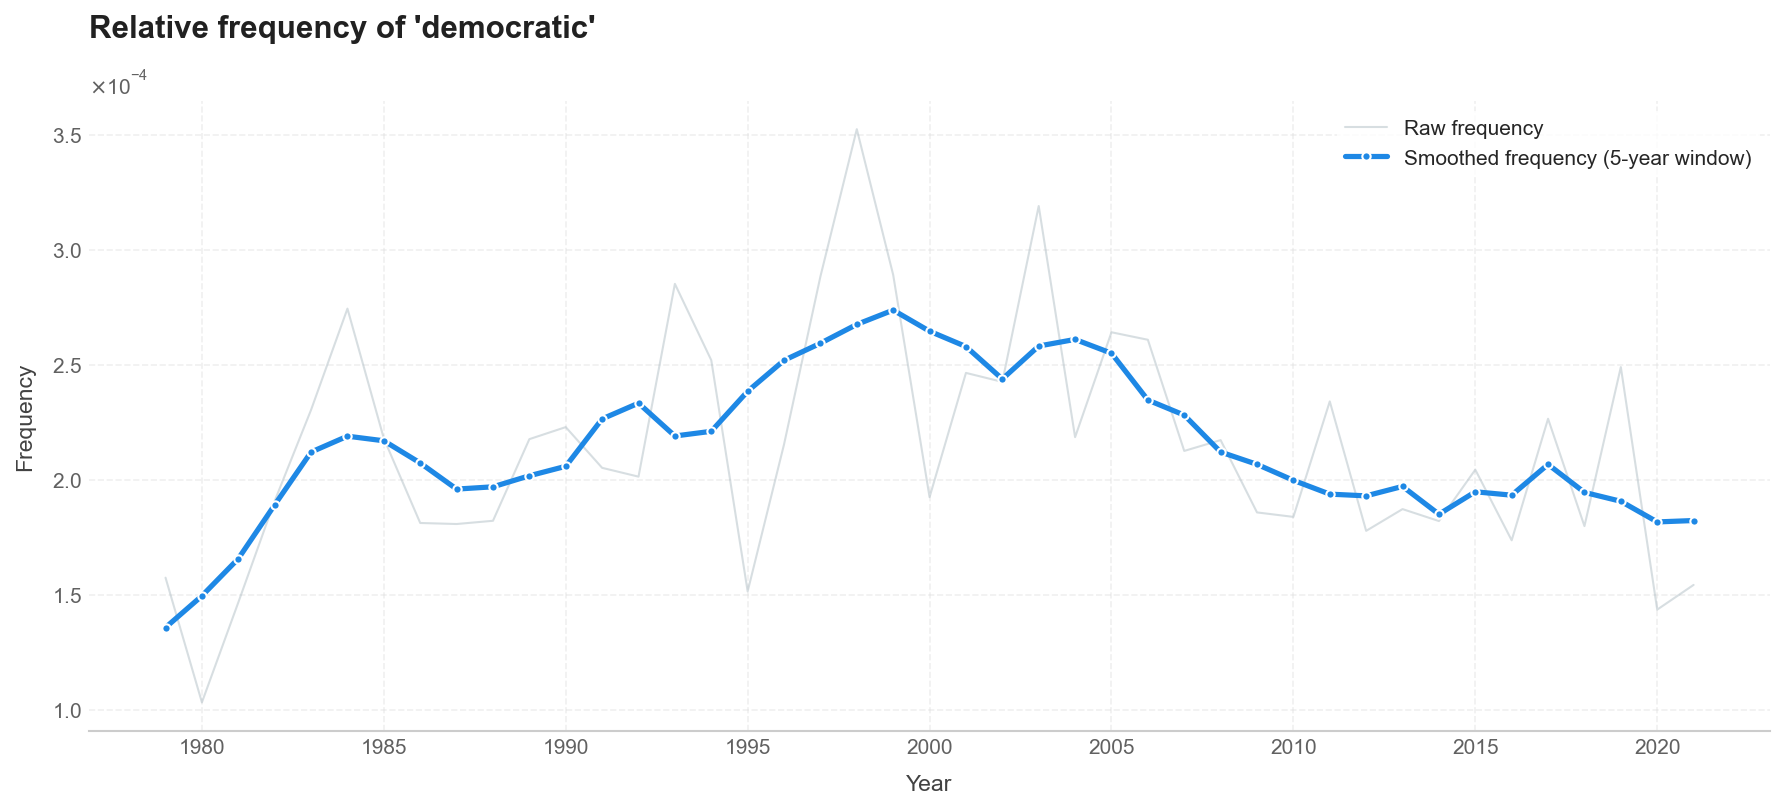

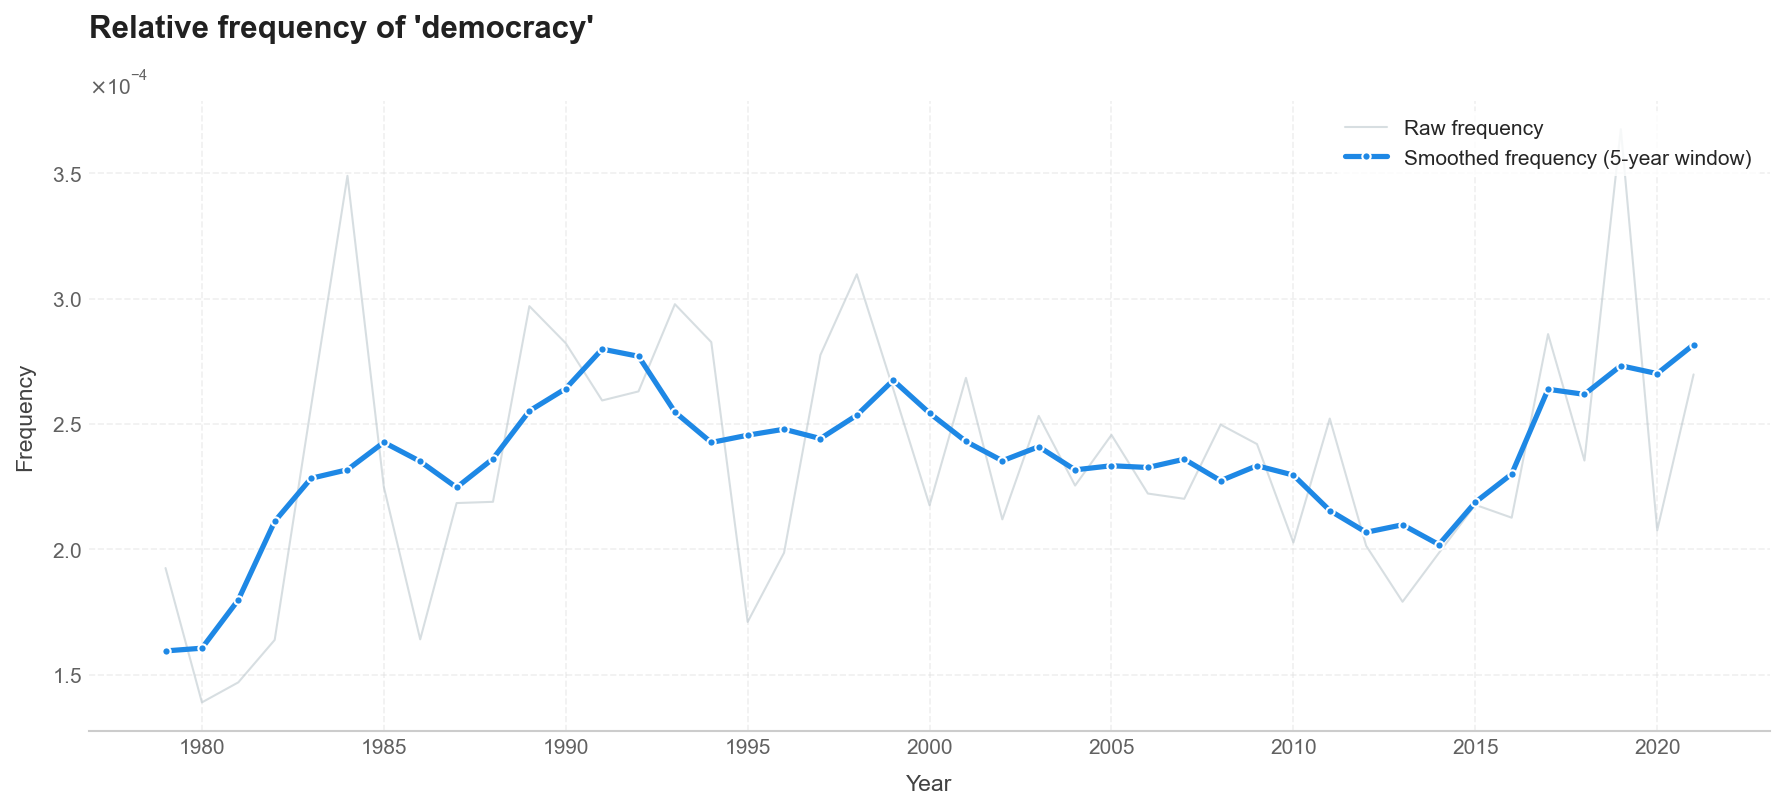

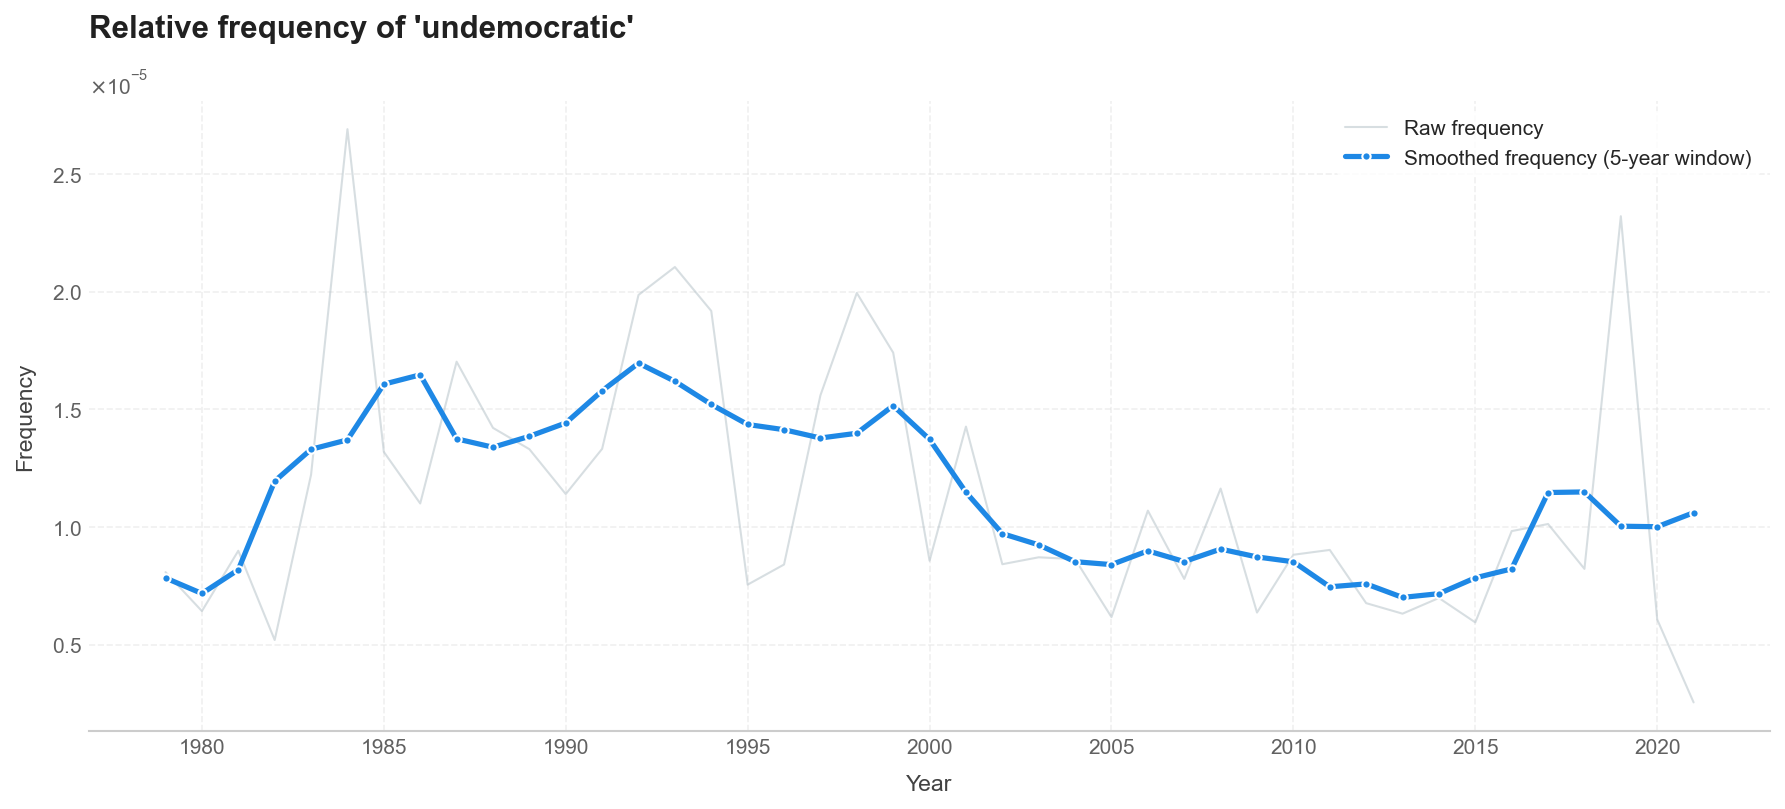

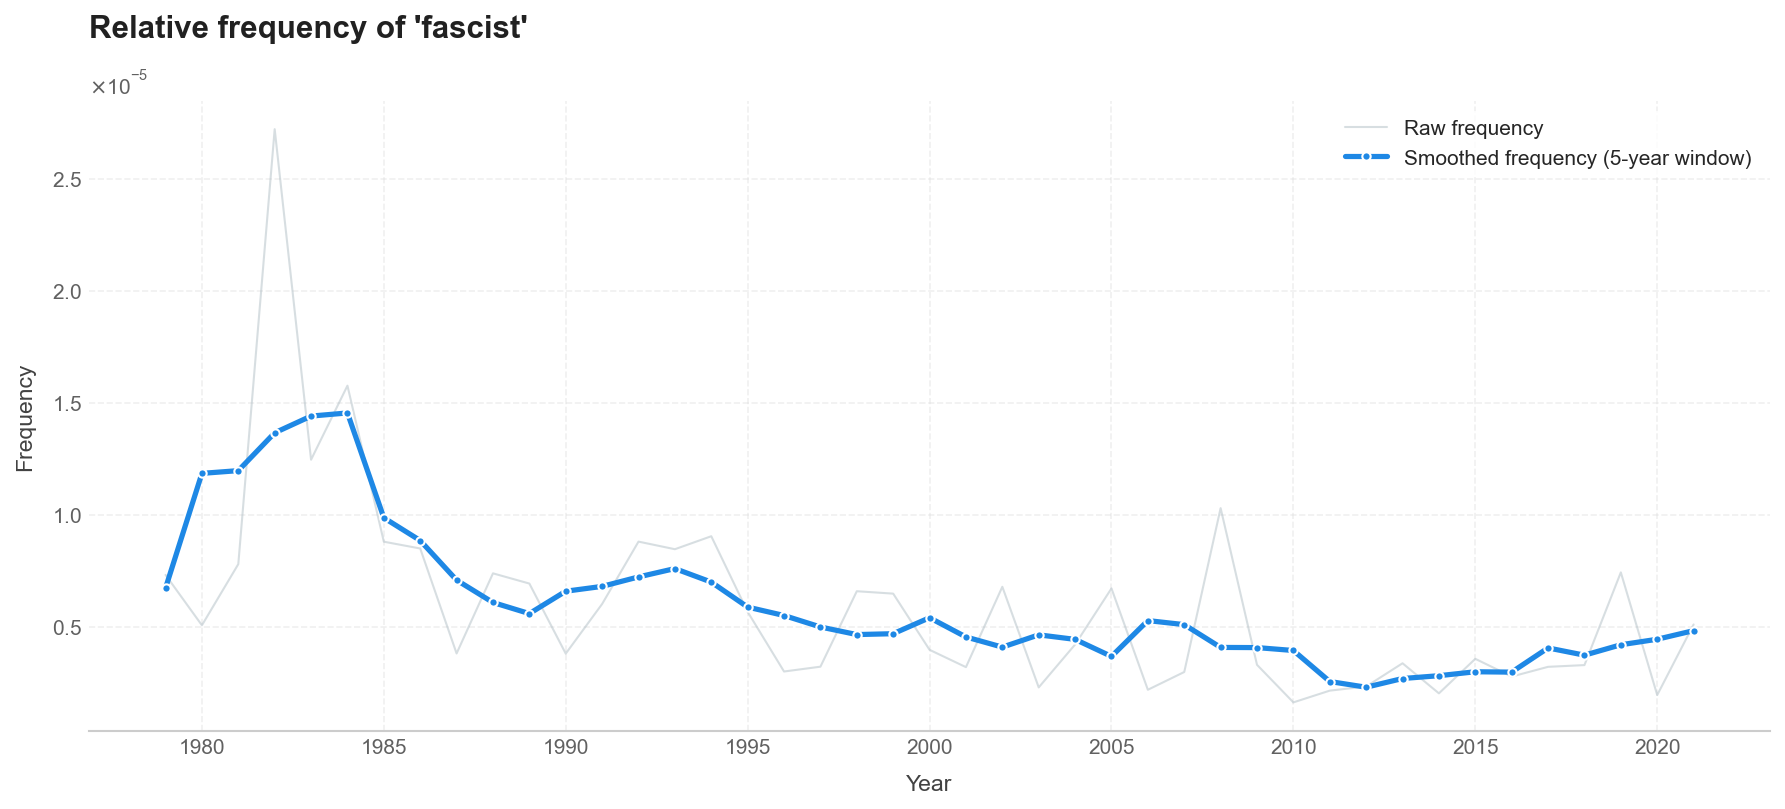

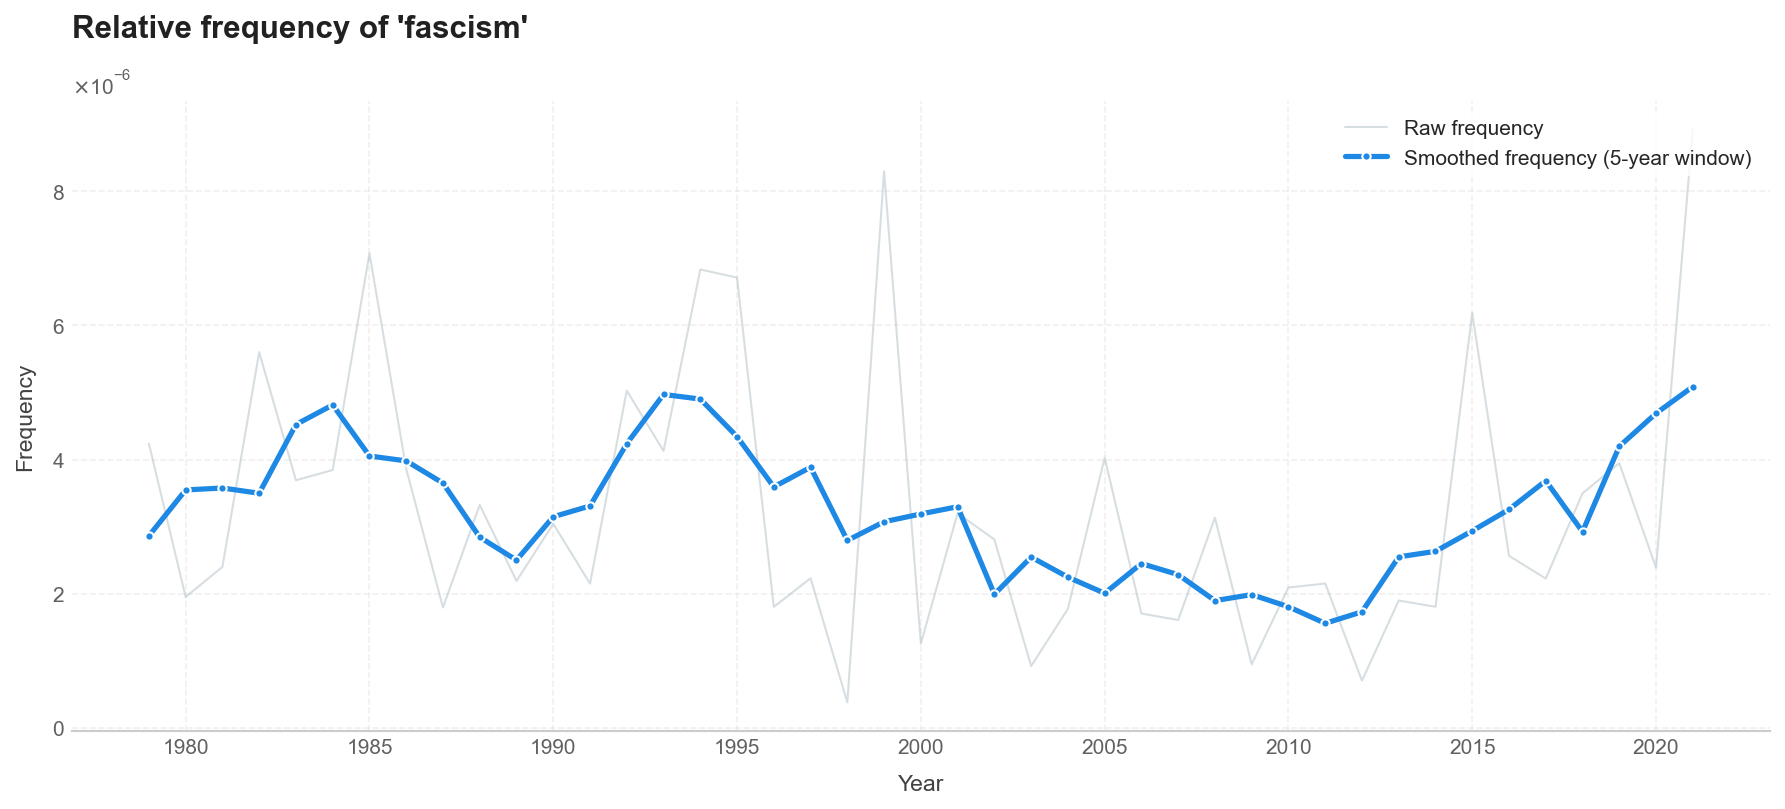

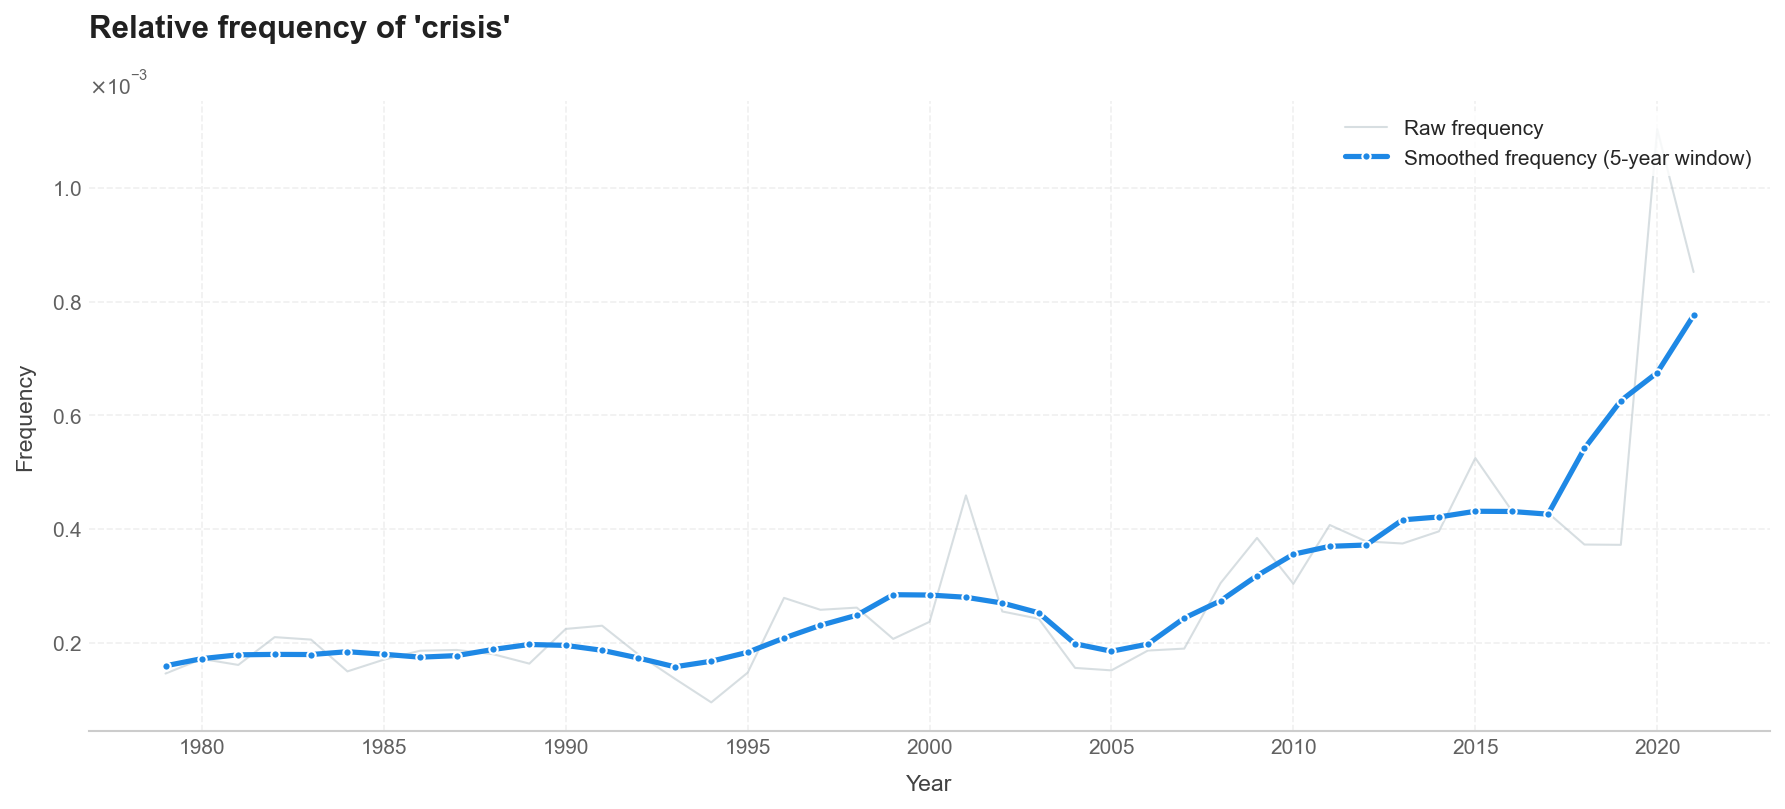

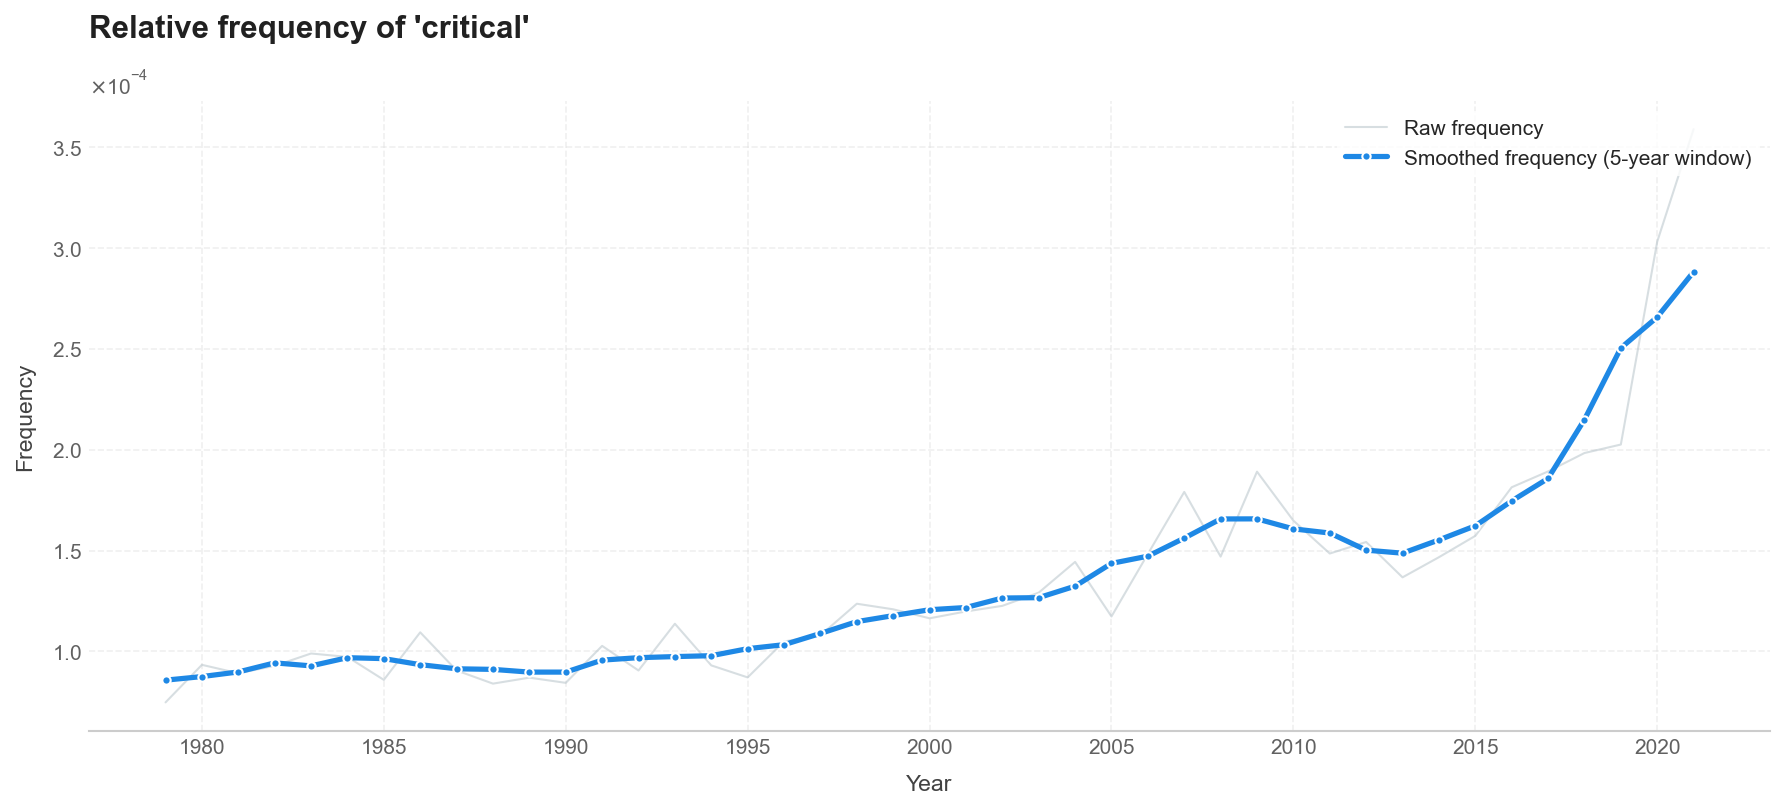

In [16]:
import matplotlib.ticker as mticker
plt.style.use("seaborn-v0_8-whitegrid") 

window_size = 5

for target_word in words_to_find:
    csv_path = f"/Users/inqfinity/mip/relative_frequency_outputs/{target_word}_relative_freq.csv"
    results_df = pd.read_csv(csv_path)
    
    custom_smooth_col = f"smoothed_{window_size}yr"
    results_df[custom_smooth_col] = (results_df["relative_freq"].rolling(window=window_size, center=True, min_periods=1).mean())
    
    fig, ax = plt.subplots(figsize=(12, 5.5), dpi=150)
    
    ax.plot(results_df["year"], results_df["relative_freq"], label="Raw frequency", color="#B0BEC5", linewidth=1, alpha=0.5)
    
    ax.plot(results_df["year"], results_df[custom_smooth_col], label=f"Smoothed frequency ({window_size}-year window)", color="#1E88E5", linewidth=2.5, marker="o", markersize=4, markeredgecolor="white") #smoothened plot
 
    ax.grid(True, linestyle="--", alpha=0.5, color="#E0E0E0", which="both")
    
    for spine in ["top", "right", "left", "right"]: ax.spines[spine].set_visible(False)
        

    ax.set_title(f"Relative frequency of '{target_word}'", fontsize=15, fontweight="bold", pad=15, color="#212121", loc="left")
    
    ax.set_xlabel("Year", fontsize=11, fontweight="medium", color="#424242", labelpad=8)
    ax.set_ylabel("Frequency", fontsize=11, fontweight="medium", color="#424242", labelpad=8)
    
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style="sci", axis="y", scilimits=(0,0))
    
    ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
    
    ax.tick_params(axis="both", colors="#616161", labelsize=10)
    
    ax.legend(frameon=True, facecolor="white", edgecolor="none", shadow=False, fontsize=10, loc="upper right")
    
    plt.tight_layout()
    plt.show()

Unrelated code: checking for all party names. My next goal is to look at how parties (and seats) are divided in these relative frequencies.

In [17]:
all_parties = set()

for file in input_files:
    df = pd.read_csv(file, low_memory=False)
    all_parties.update(df["party"].dropna().unique())

sorted(all_parties)

['Alba Party',
 'Alliance',
 'Change UK - The Independent Group',
 'Conservative',
 'Conservative Independent',
 'Democratic Unionist Party',
 'Green Party',
 'Independent',
 'Independent Conservative',
 'Independent Labour',
 'Independent SDP',
 'Independent Socialist',
 'Independent Unionist',
 'Labour',
 'Labour (Co-op)',
 'Liberal',
 'Liberal Democrat',
 'Plaid Cymru',
 'Referendum',
 'Respect',
 'Scottish National Party',
 'Social Democratic & Labour Party',
 'Social Democratic Party',
 'Speaker',
 'The Independent Group for Change',
 'UK Independence Party',
 'Ulster Popular Unionist Party',
 'Ulster Progressive Unionist Party',
 'Ulster Unionist Party',
 'United Kingdom Unionist',
 'United Ulster Unionist Party']

## General Election Results
I wanted to have a look if the presences of dominating parties (or less dominant but quite outspoken parties) had any correlation with these relative frequencies. I'd like to highlight that this is correlation, not causation. I found some data on UK General Elections on this website: [https://electiondatavault.co.uk/charts/election-results/](https://electiondatavault.co.uk/charts/election-results/) and extracted the `.csv` files. I then created an overlay.

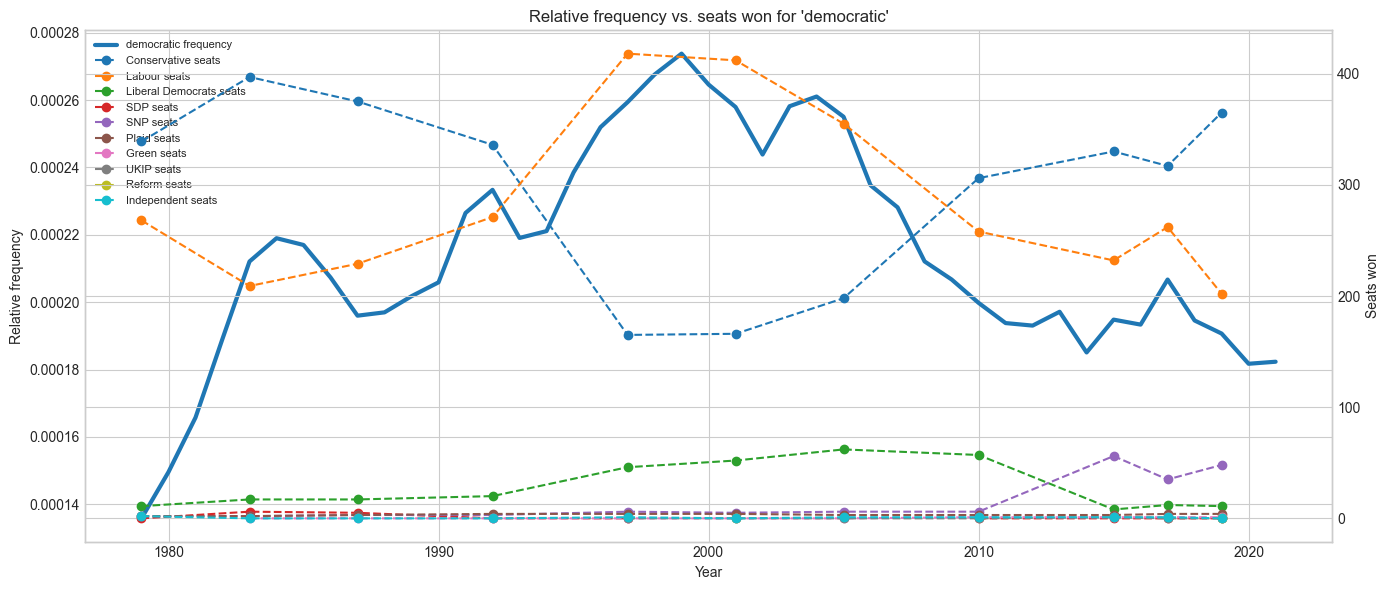

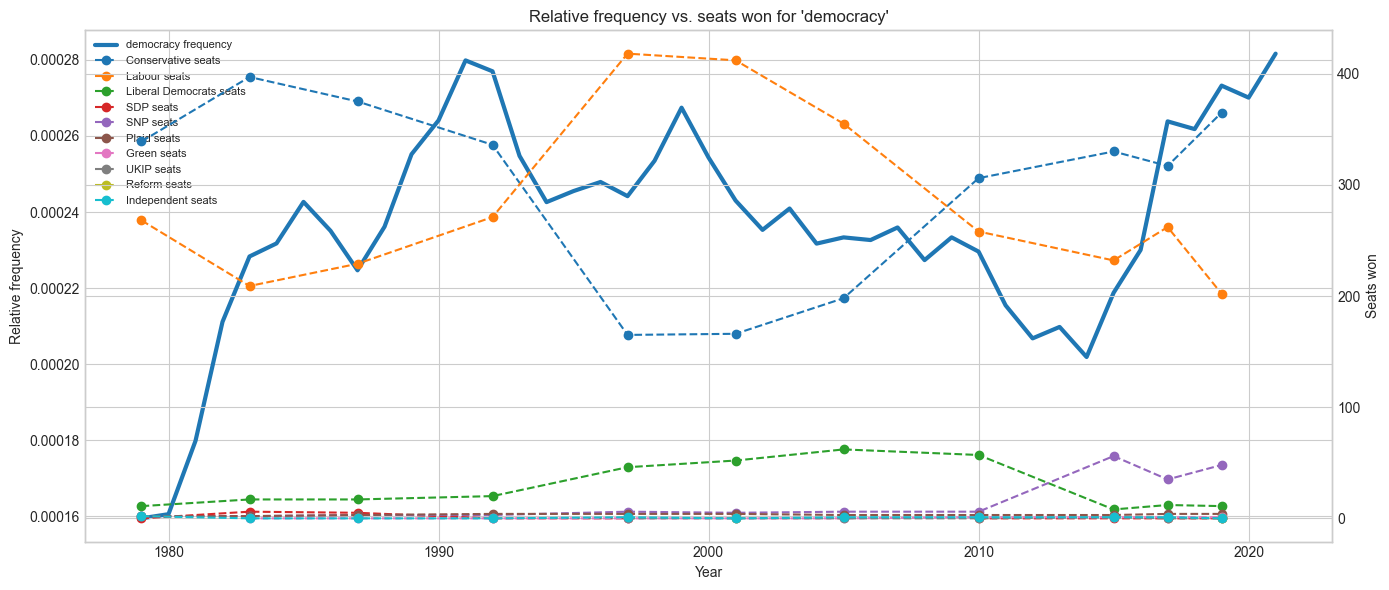

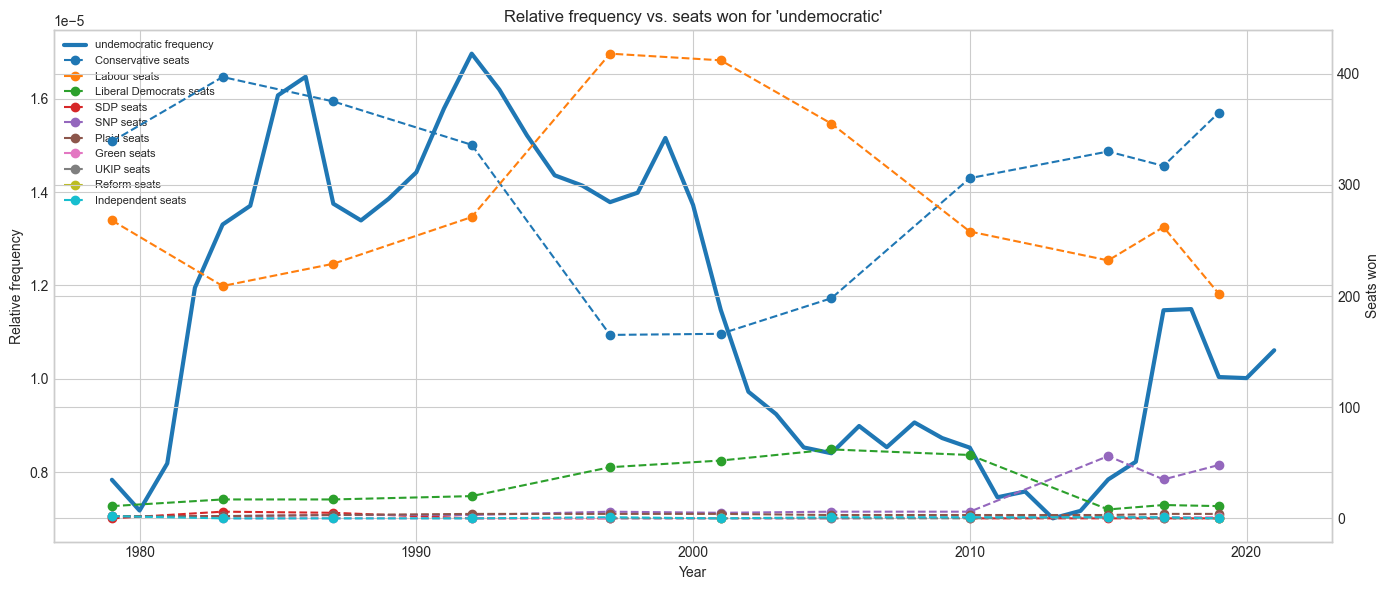

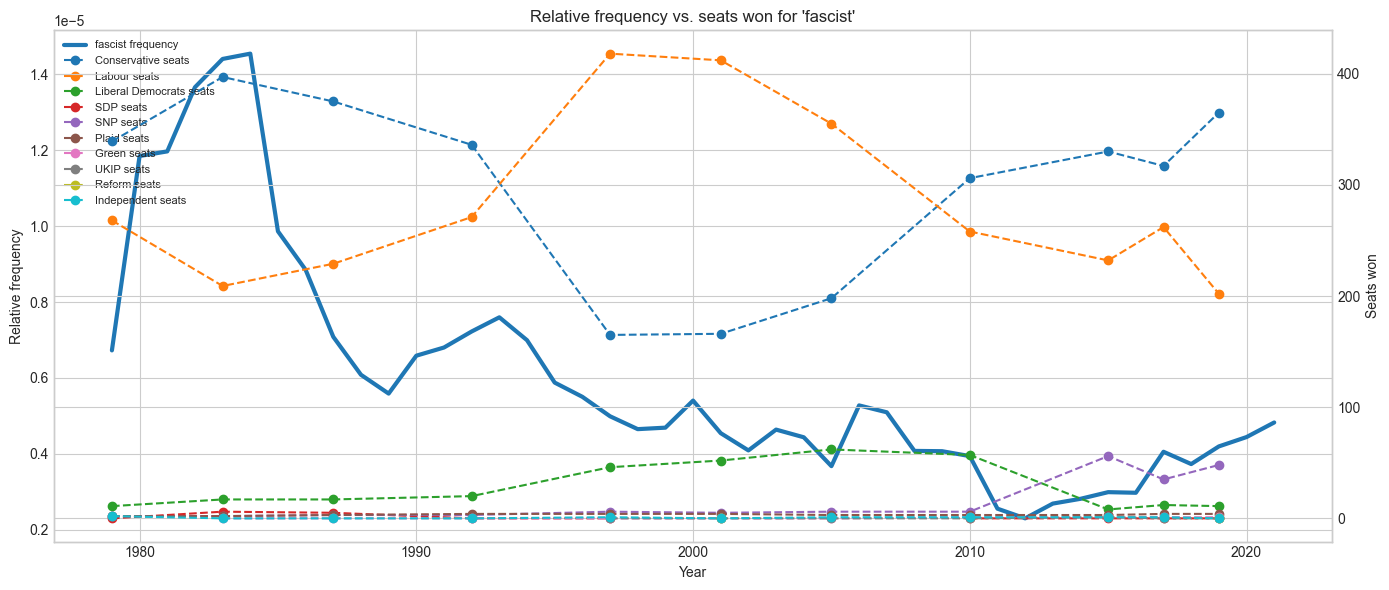

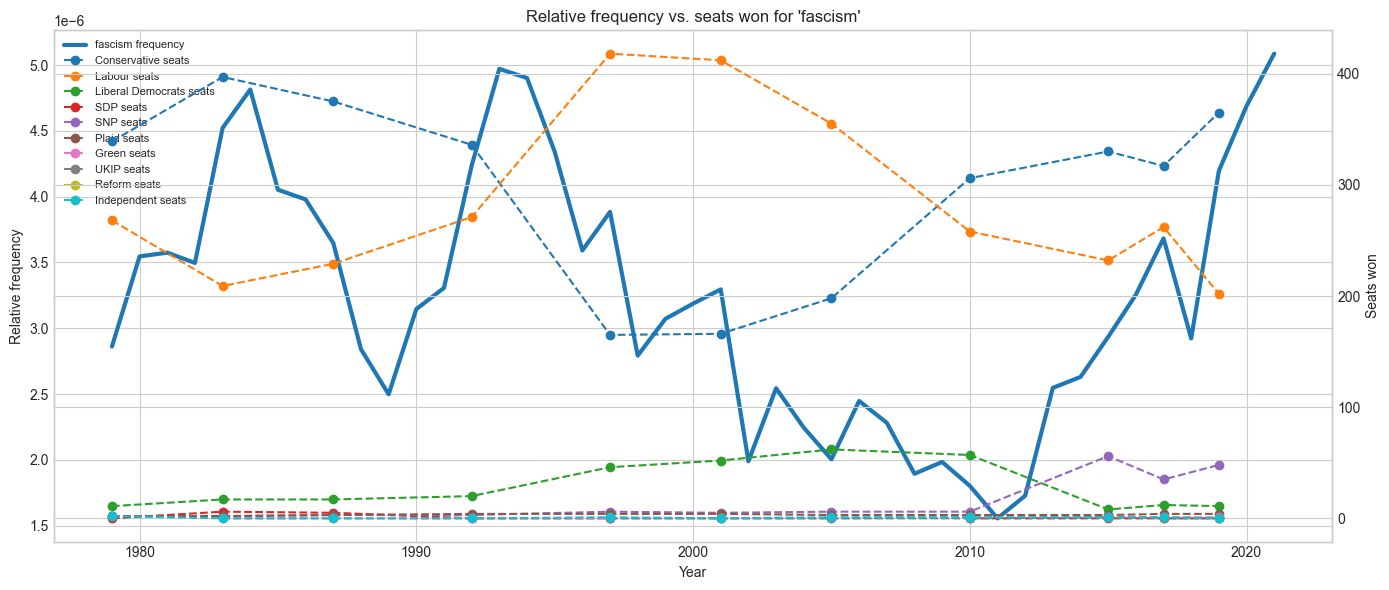

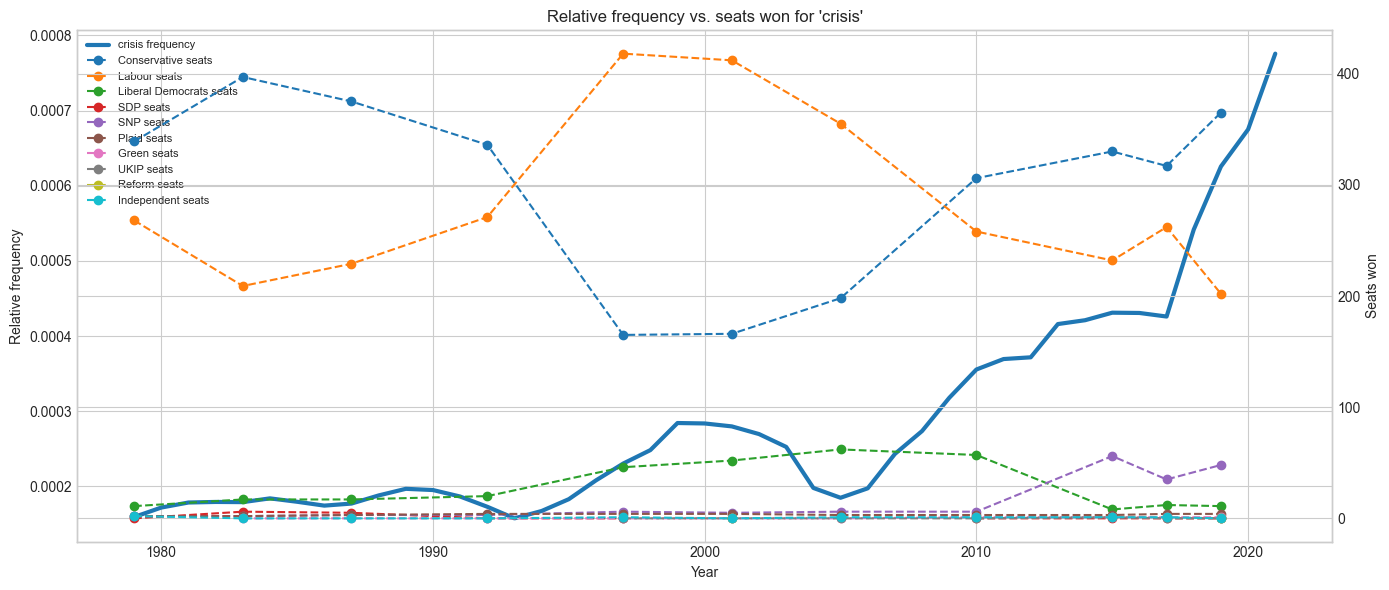

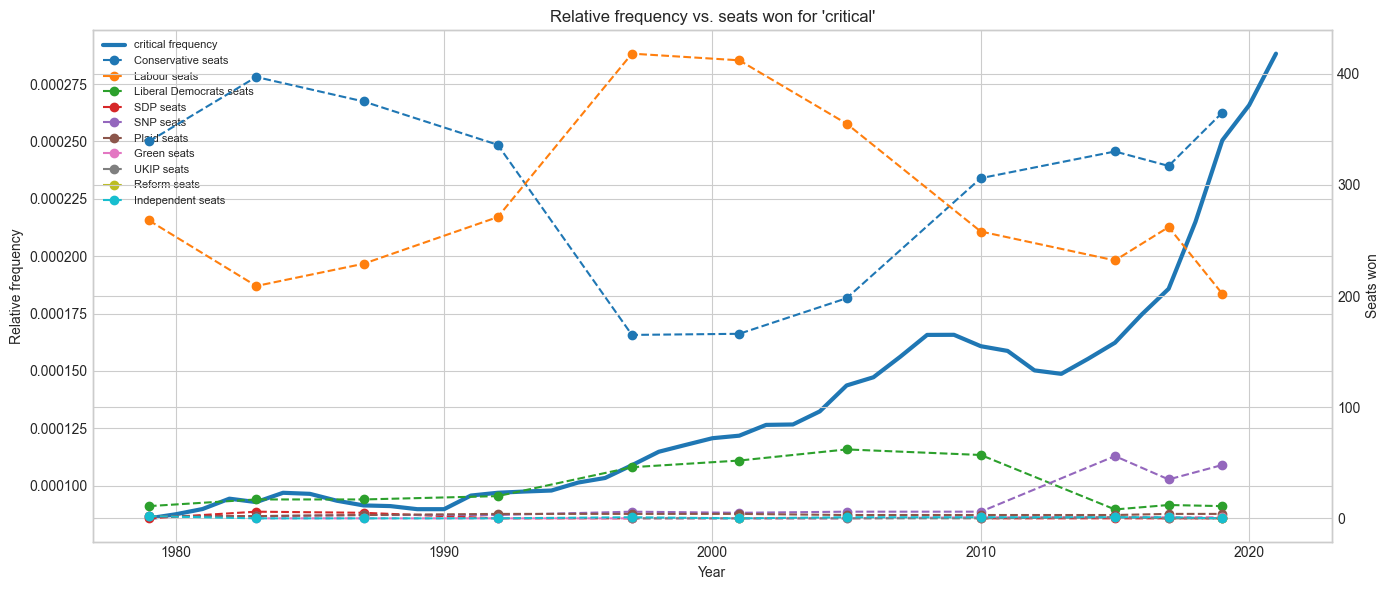

In [18]:
seats_path = "/Users/inqfinity/mip/Seats Won in General Elections 1955-2024.csv"

seats_df = pd.read_csv(seats_path, sep=";", skiprows=[1])

seats_df = seats_df.rename(columns={"electionyear": "year"})
seats_df["year"] = seats_df["year"].astype(int)

seats_df = seats_df[(seats_df["year"] >= 1979) & (seats_df["year"] <= 2021)]

parties_to_plot = [col for col in seats_df.columns if col != "year"]

for target_word in words_to_find:

    freq_path = f"{output_folder}/{target_word}_relative_freq.csv"

    results_df = pd.read_csv(freq_path)

    fig, ax1 = plt.subplots(figsize=(14, 6))

    ax1.plot(results_df["year"], results_df["smoothed_frequency"], linewidth=3, label=f"{target_word} frequency") #first plot freq

    ax1.set_xlabel("Year")
    ax1.set_ylabel("Relative frequency")

    ax2 = ax1.twinx()

    for party in seats_df.columns:
        if party != "year":
            ax2.plot(seats_df["year"], seats_df[party], linestyle="--", marker="o", label=f"{party} seats")
    ax2.set_ylabel("Seats won")

    lines1, labels1 = ax1.get_legend_handles_labels() #put em legends tgt
    lines2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)

    plt.title(f"Relative frequency vs. seats won for '{target_word}'")

    plt.tight_layout()
    plt.show()

As the plots above look really overwhelming, I just asked AI to use `seaborn` to re-do my code above for me wiht some better aesthetics. I could also do this myself, but I hope you understand that it's not worth my time to keep modifying and adjusting every little thing just to re-plot everything aesthetically! Now, it is also easier to read!

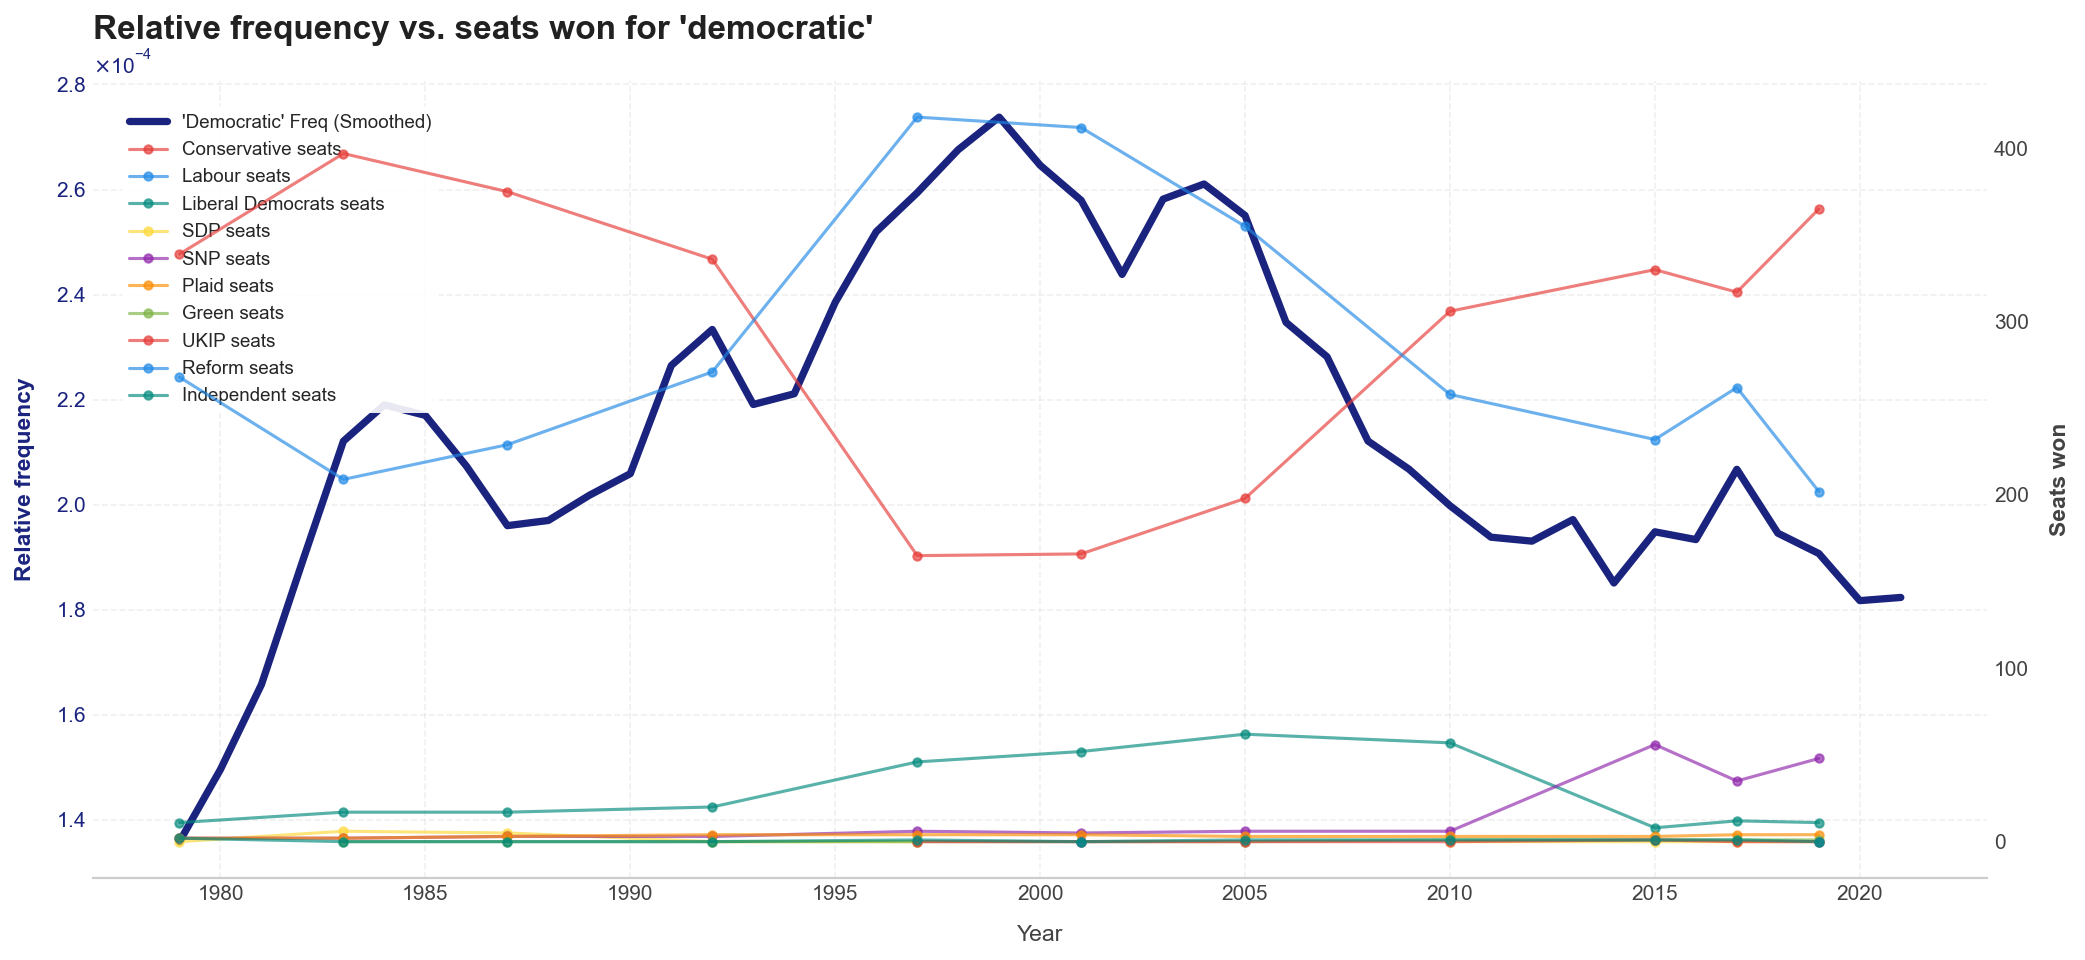

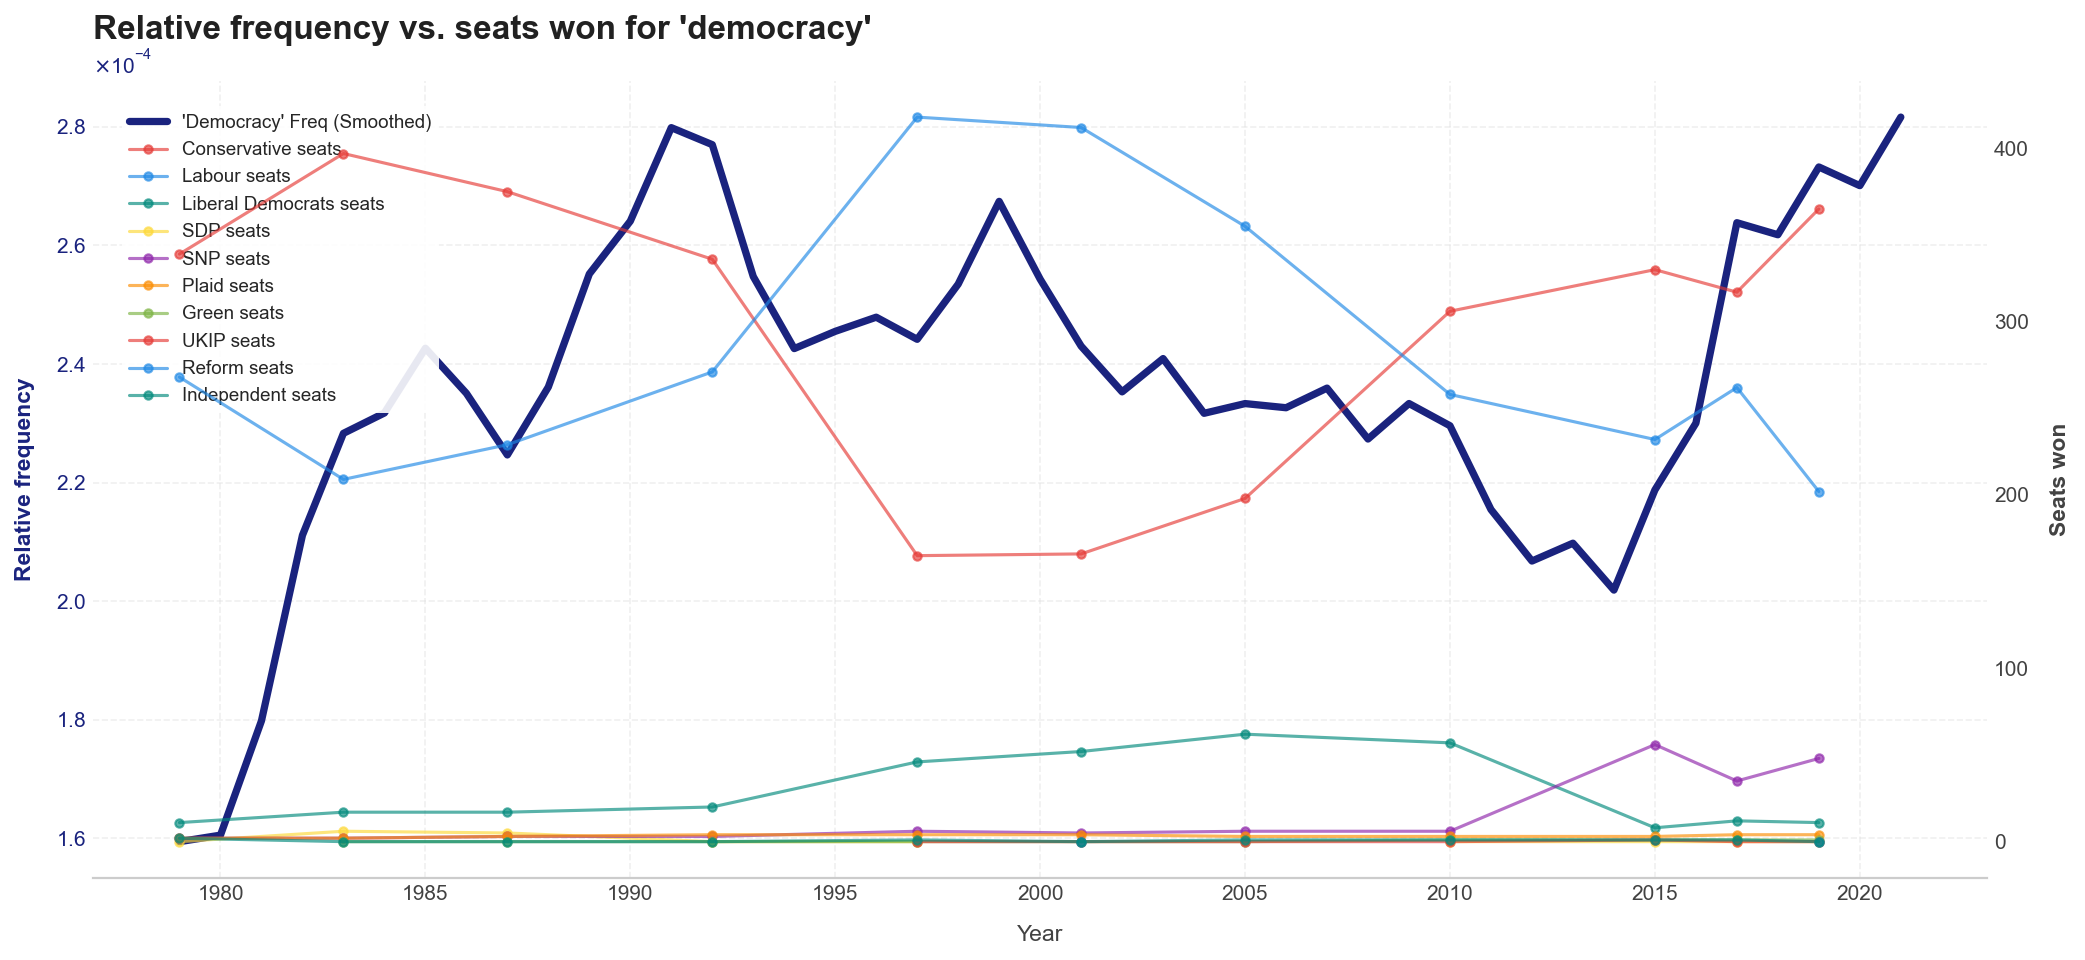

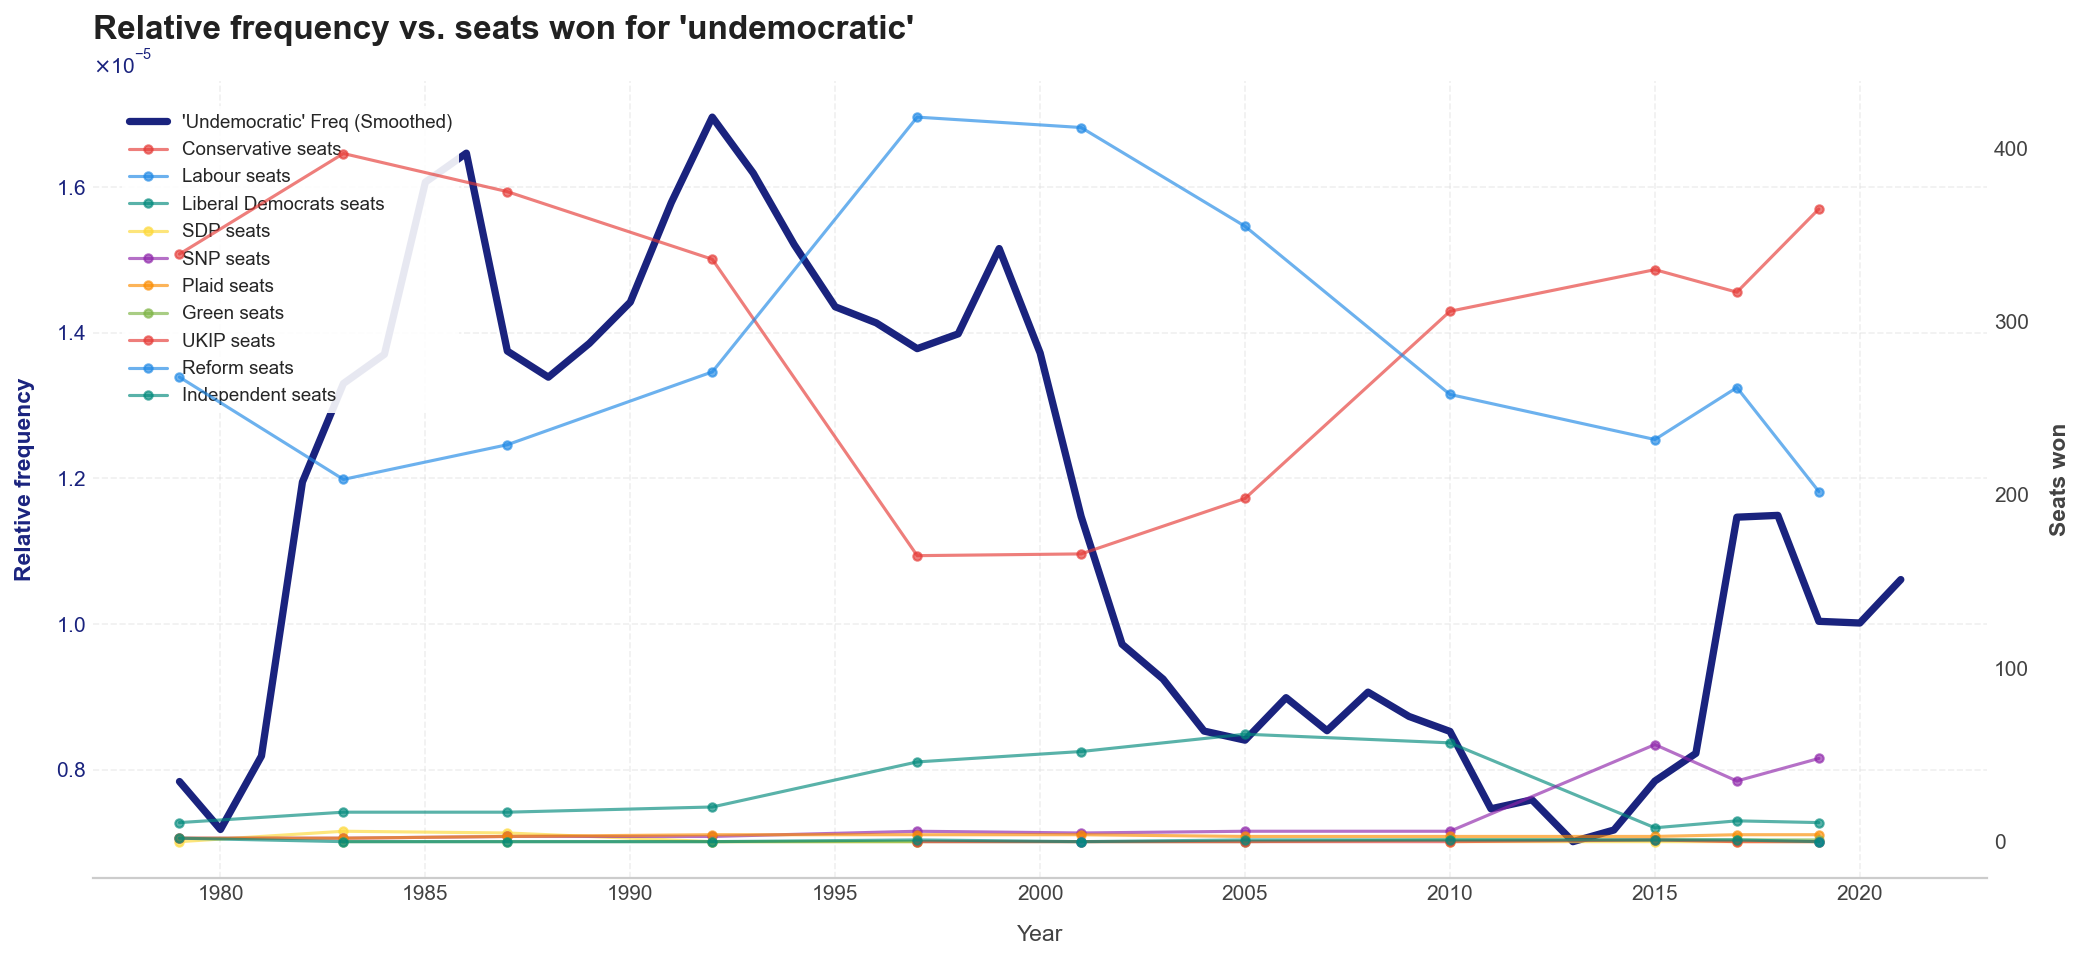

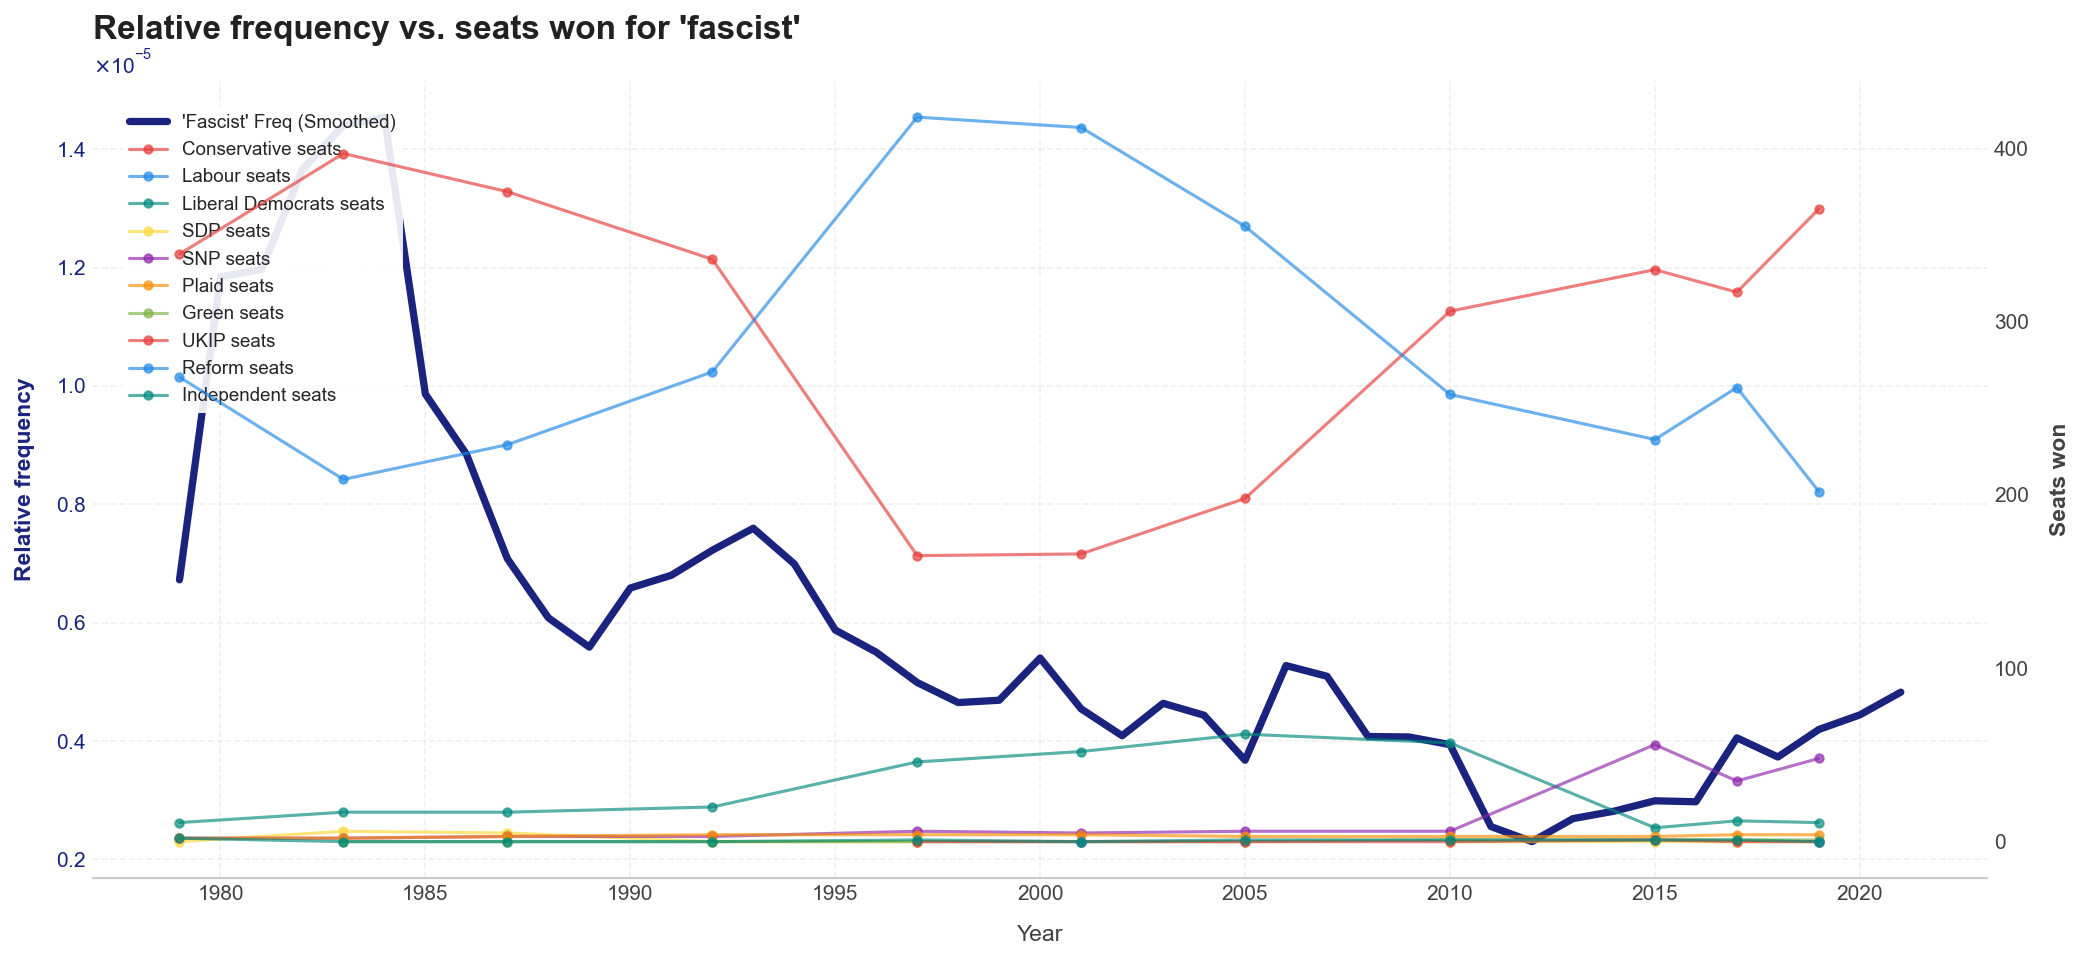

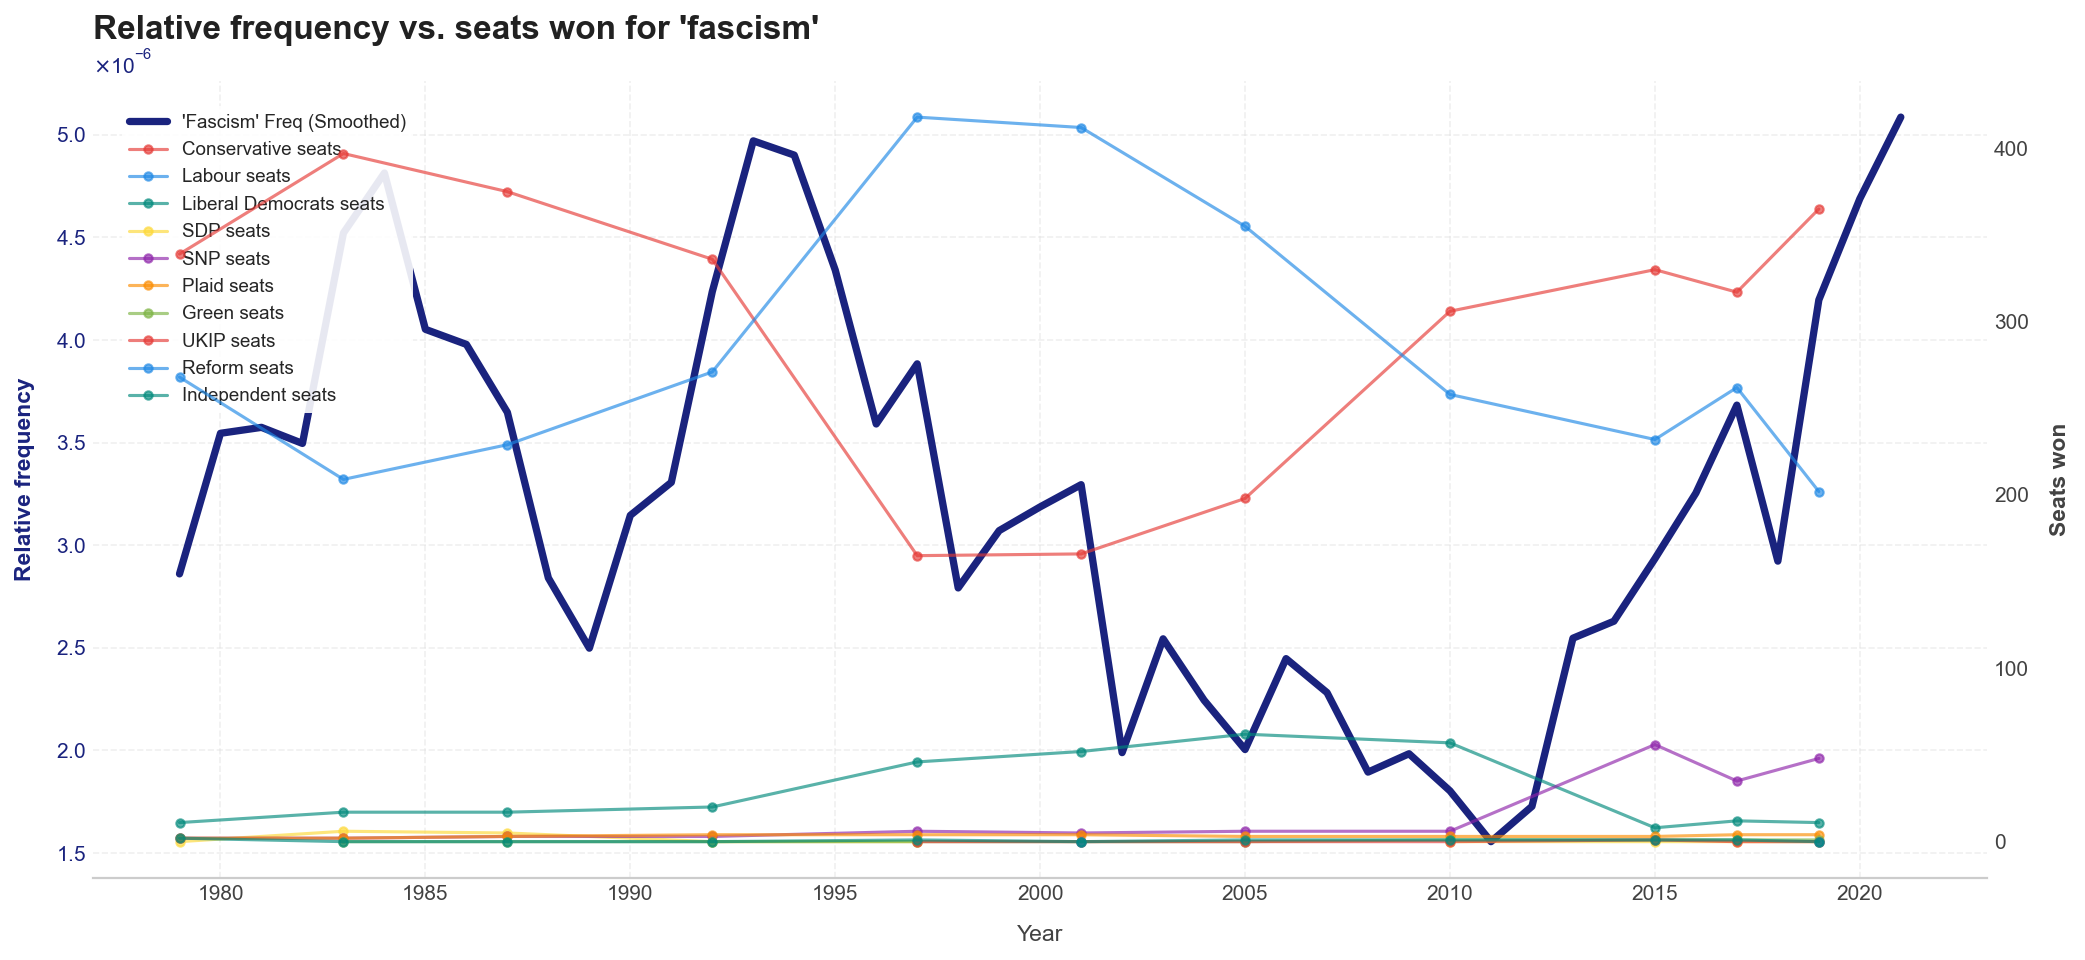

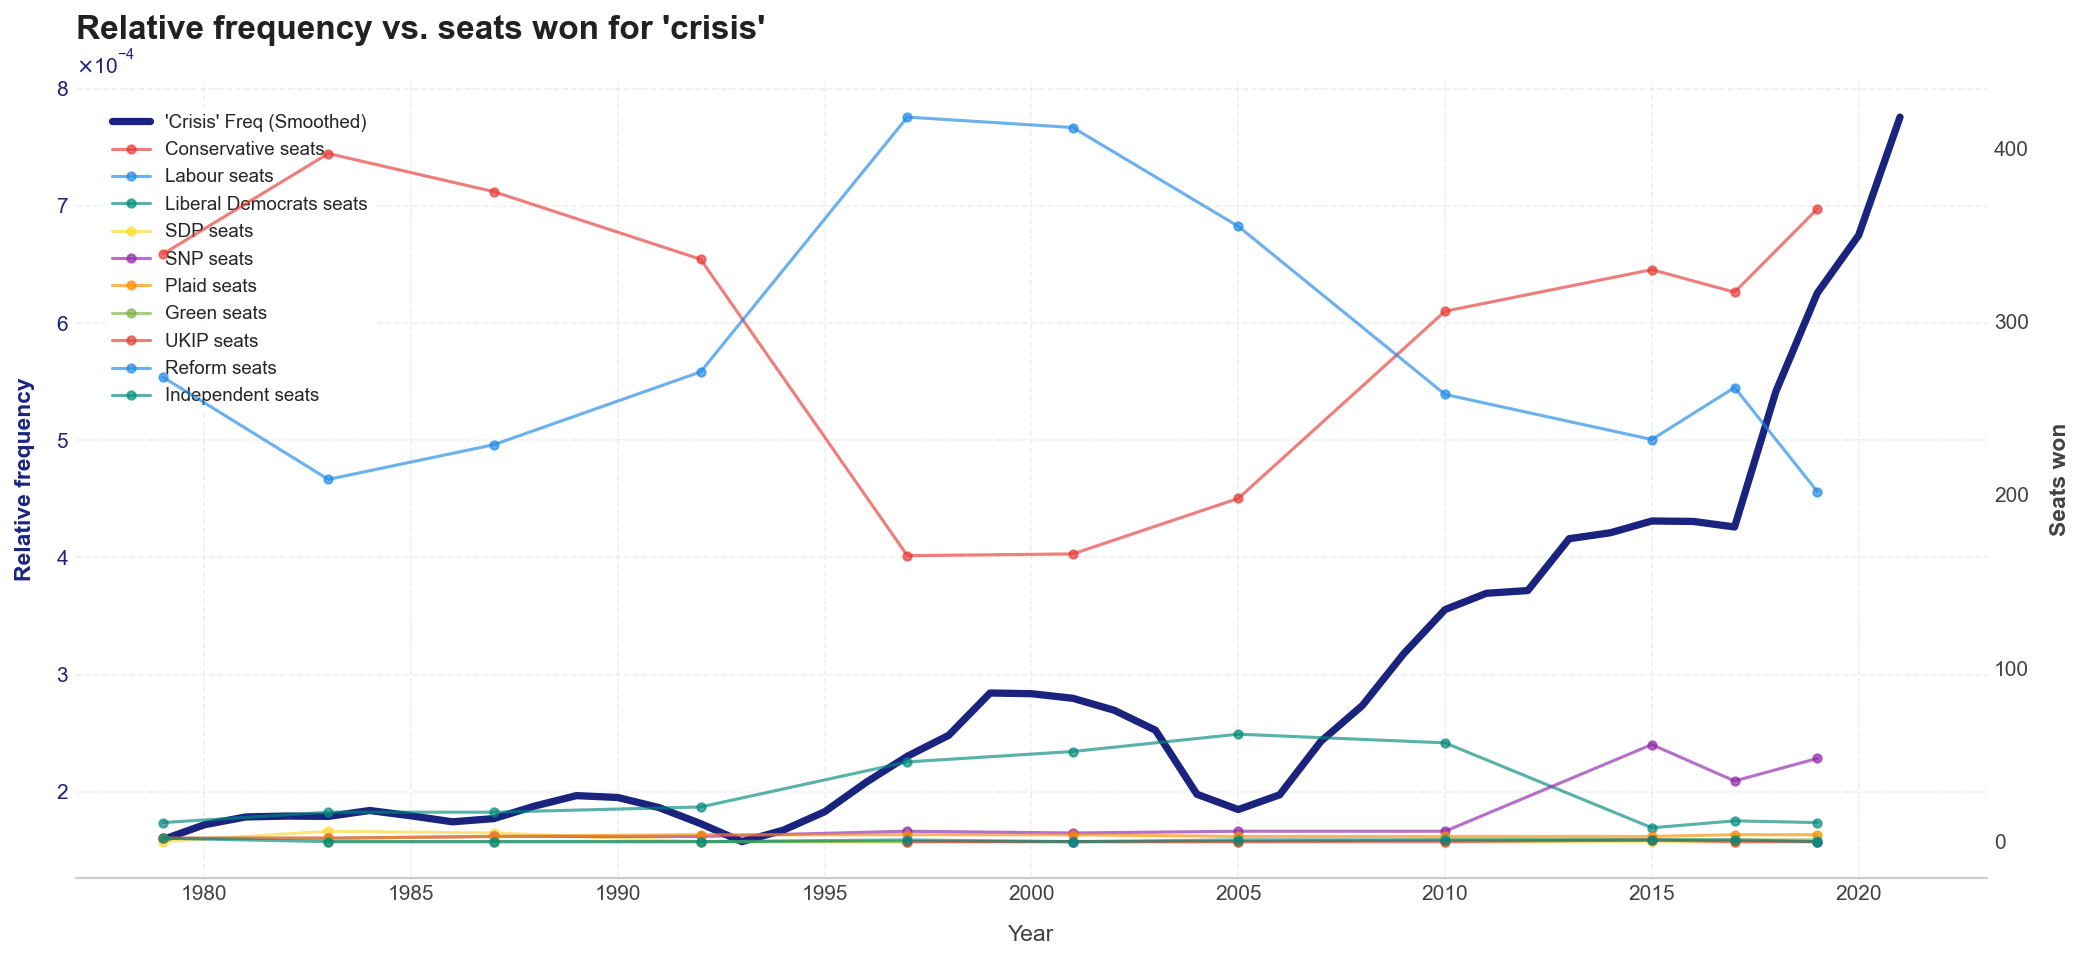

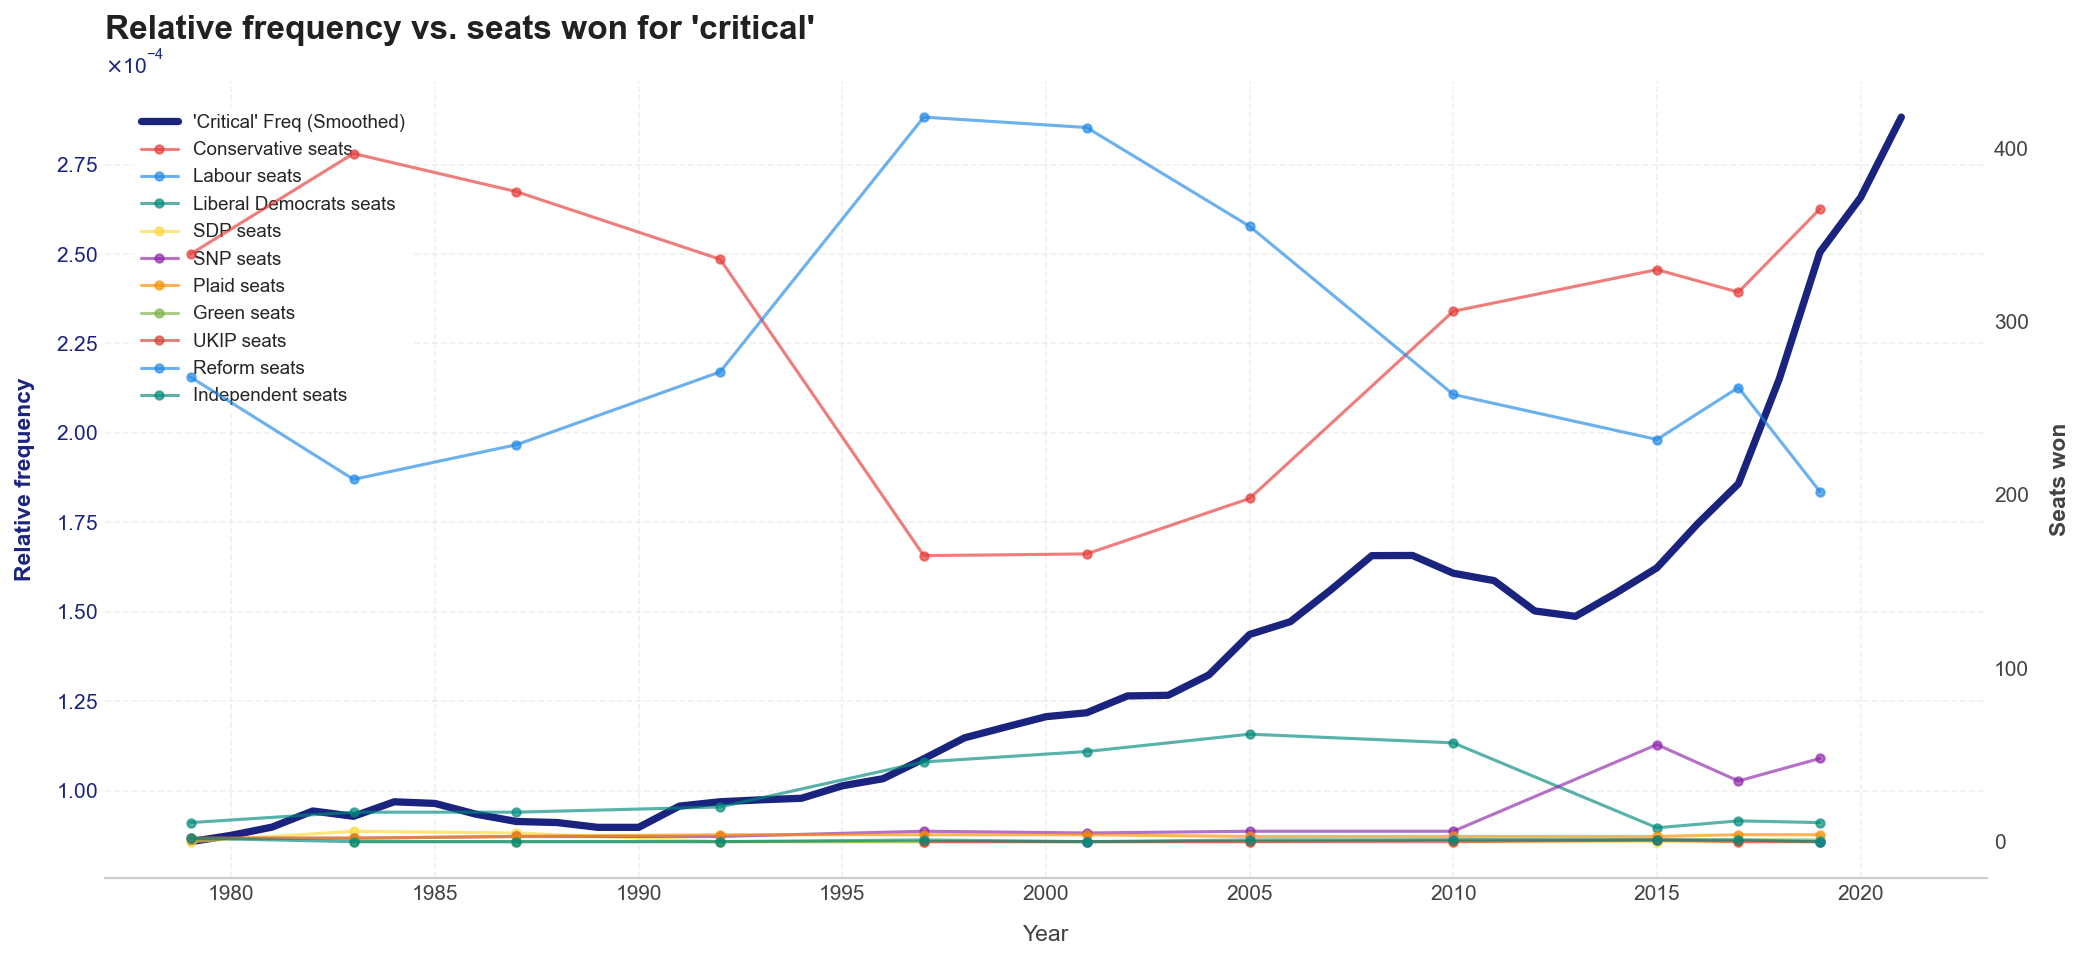

In [19]:
plt.style.use("seaborn-v0_8-whitegrid") 

seats_path = "/Users/inqfinity/mip/Seats Won in General Elections 1955-2024.csv"
seats_df = pd.read_csv(seats_path, sep=";", skiprows=[1])
seats_df = seats_df.rename(columns={"electionyear": "year"})
seats_df["year"] = seats_df["year"].astype(int)
seats_df = seats_df[(seats_df["year"] >= 1979) & (seats_df["year"] <= 2021)]

party_colors = ["#E53935", "#1E88E5", "#00897B", "#FDD835", "#8E24AA", "#FB8C00", "#7CB342"]

for target_word in words_to_find:
    freq_path = f"{output_folder}/{target_word}_relative_freq.csv"
    results_df = pd.read_csv(freq_path)

    fig, ax1 = plt.subplots(figsize=(14, 6.5), dpi=150)

    line_freq = ax1.plot(
        results_df["year"], results_df["smoothed_frequency"], 
        linewidth=3.5, color="#1A237E", label=f"'{target_word.capitalize()}' Freq (Smoothed)"
    )

    ax1.set_xlabel("Year", fontsize=11, fontweight="medium", color="#424242", labelpad=10)
    ax1.set_ylabel("Relative frequency", fontsize=11, fontweight="bold", color="#1A237E", labelpad=10)

    ax1.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    ax1.ticklabel_format(style="sci", axis="y", scilimits=(0,0))
    ax1.tick_params(axis="y", labelcolor="#1A237E", labelsize=10)
    ax1.tick_params(axis="x", labelcolor="#424242", labelsize=10)

    ax1.grid(True, linestyle="--", alpha=0.5, color="#E0E0E0")

    ax2 = ax1.twinx()

    color_idx = 0
    for party in seats_df.columns:
        if party != "year":
            current_color = party_colors[color_idx % len(party_colors)]
            ax2.plot(
                seats_df["year"], seats_df[party], 
                linestyle="-", linewidth=1.5, alpha=0.65, 
                marker="o", markersize=4, color=current_color, label=f"{party} seats"
            )
            color_idx += 1

    ax2.set_ylabel("Seats won", fontsize=11, fontweight="bold", color="#424242", labelpad=10)
    ax2.tick_params(axis="y", labelcolor="#424242", labelsize=10)

    ax2.grid(False)

    for ax in [ax1, ax2]:
        for spine in ["top", "left", "right"]:
            ax.spines[spine].set_visible(False)

    ax1.set_title(f"Relative frequency vs. seats won for '{target_word}'", fontsize=16, fontweight="bold", pad=20, color="#212121", loc="left")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    
    ax1.legend(
        lines1 + lines2, labels1 + labels2, 
        loc="upper left", bbox_to_anchor=(0.01, 0.98),
        frameon=True, facecolor="white", edgecolor="none", framealpha=0.9, fontsize=9
    )

    ax1.xaxis.set_major_locator(mticker.MultipleLocator(5))

    plt.tight_layout()
    plt.show()

## Share of Votes
Another thing I found on the website (with vote data) is that they also have data for the share or % of votes. I find this particularly useful, as we know that the number of seats don't always accurately represent the votes a party has received (or their popularity). For instance, UKIP isn't well-represented if you look at the number of seats they (barely) received in Parliament, but we do know that they are very outspoken on certain issues, like Euroskepticism, and also gained popularity around the time of Brexit. Thus, I'd like to also look more so at the share of votes.

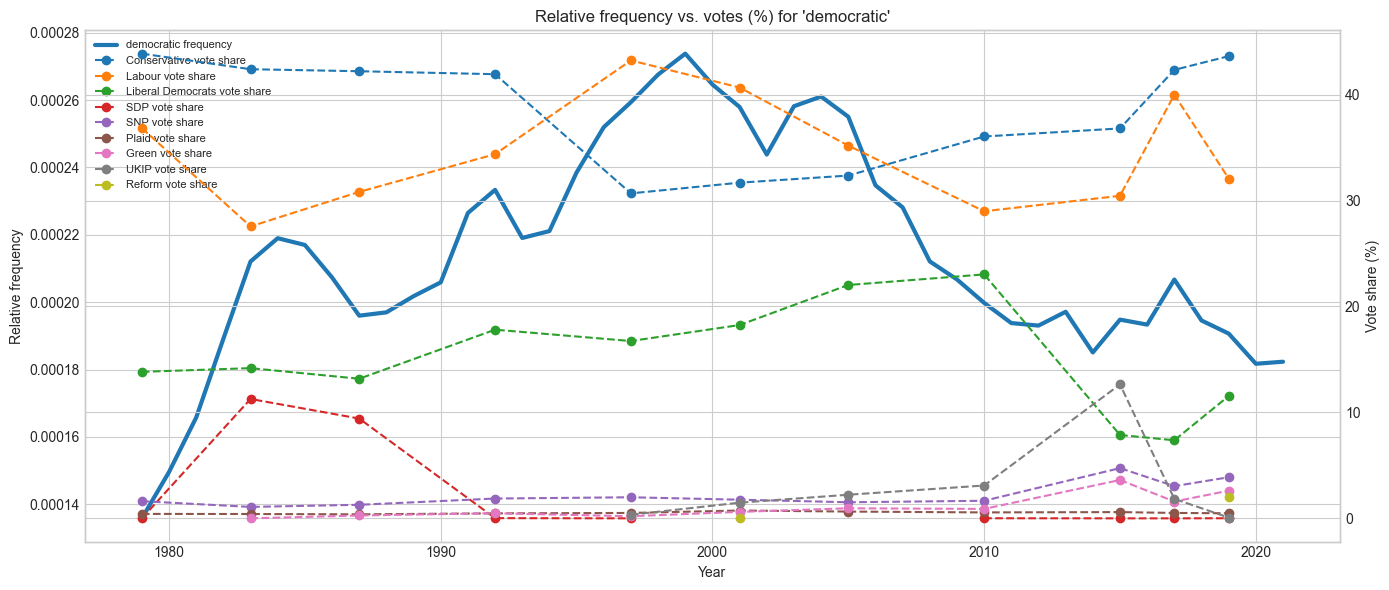

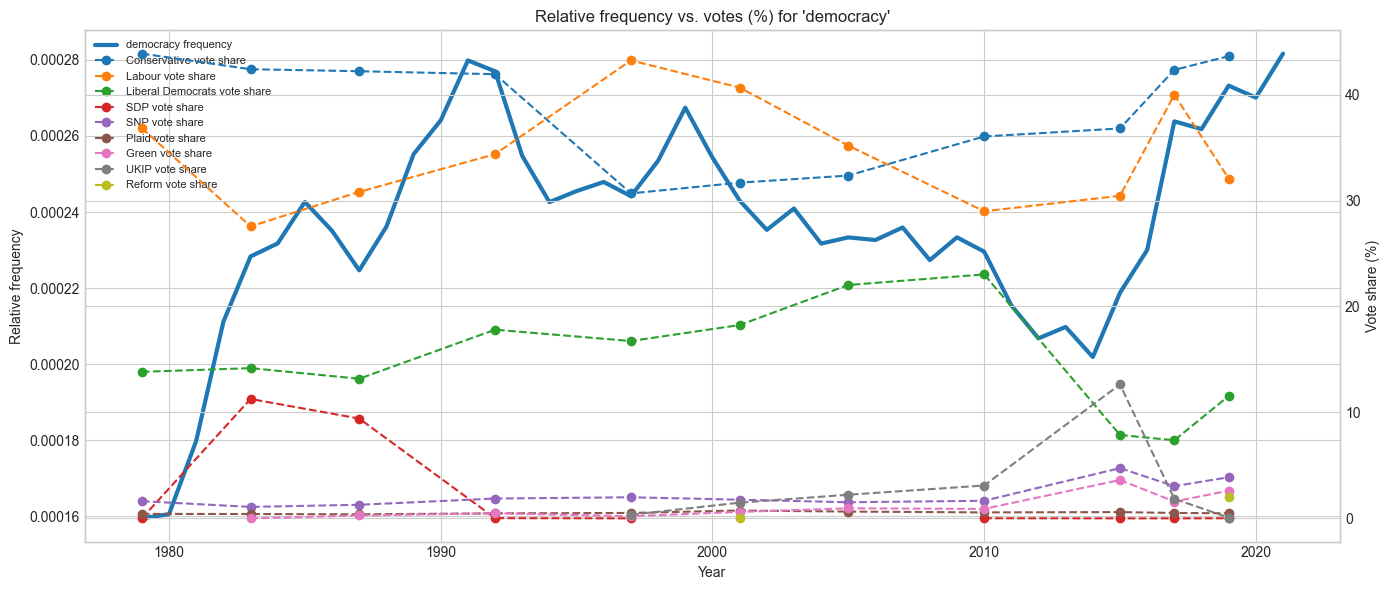

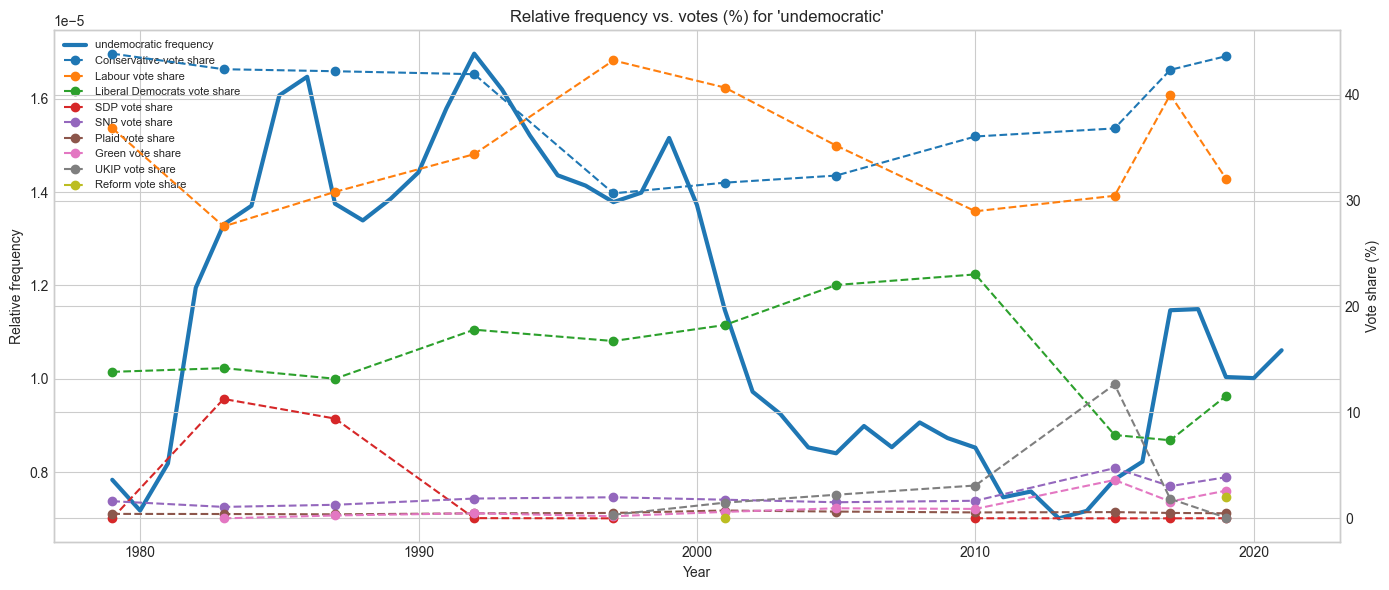

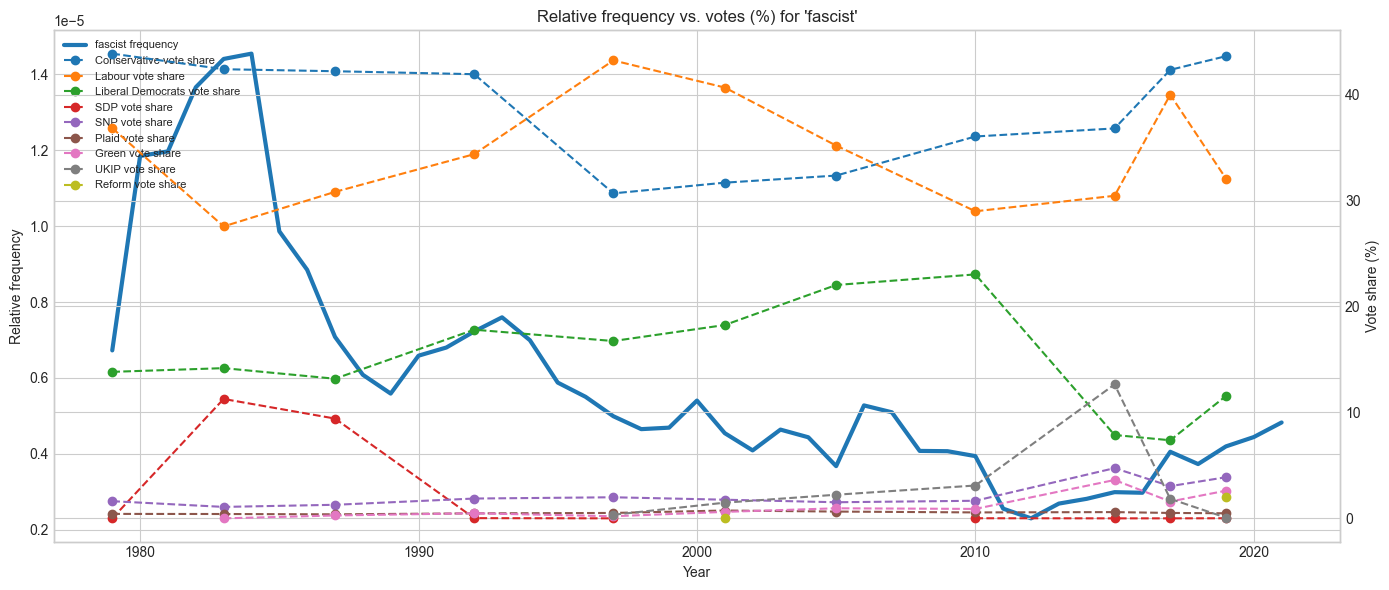

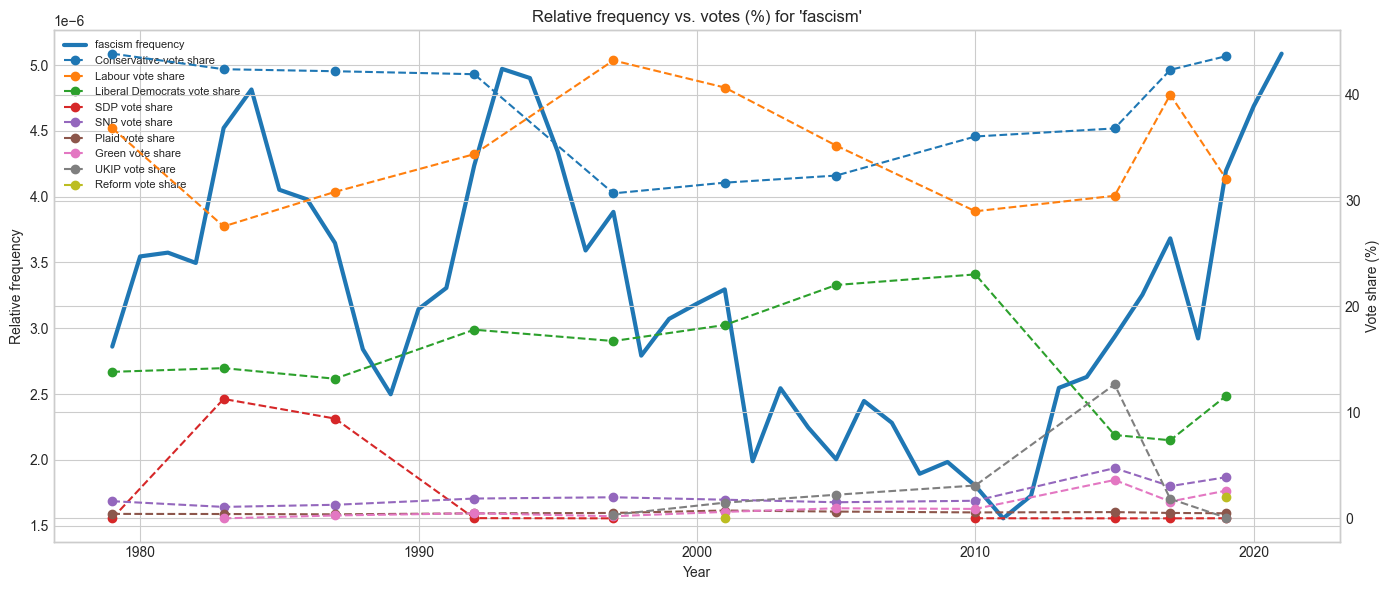

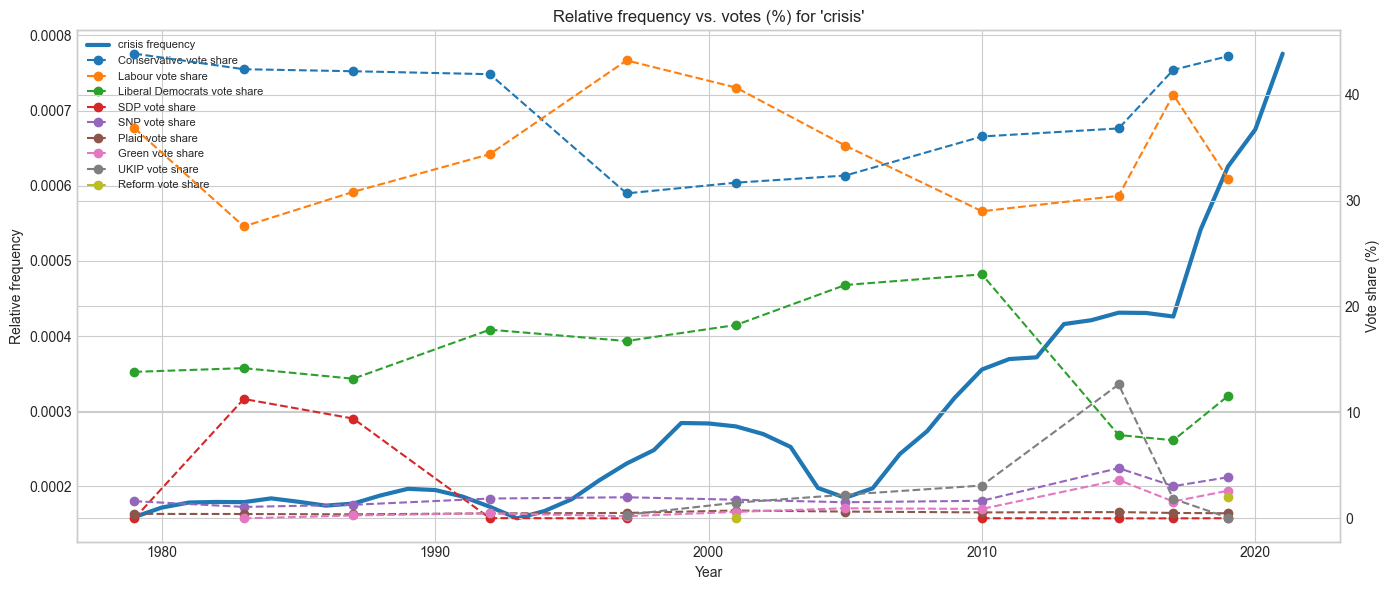

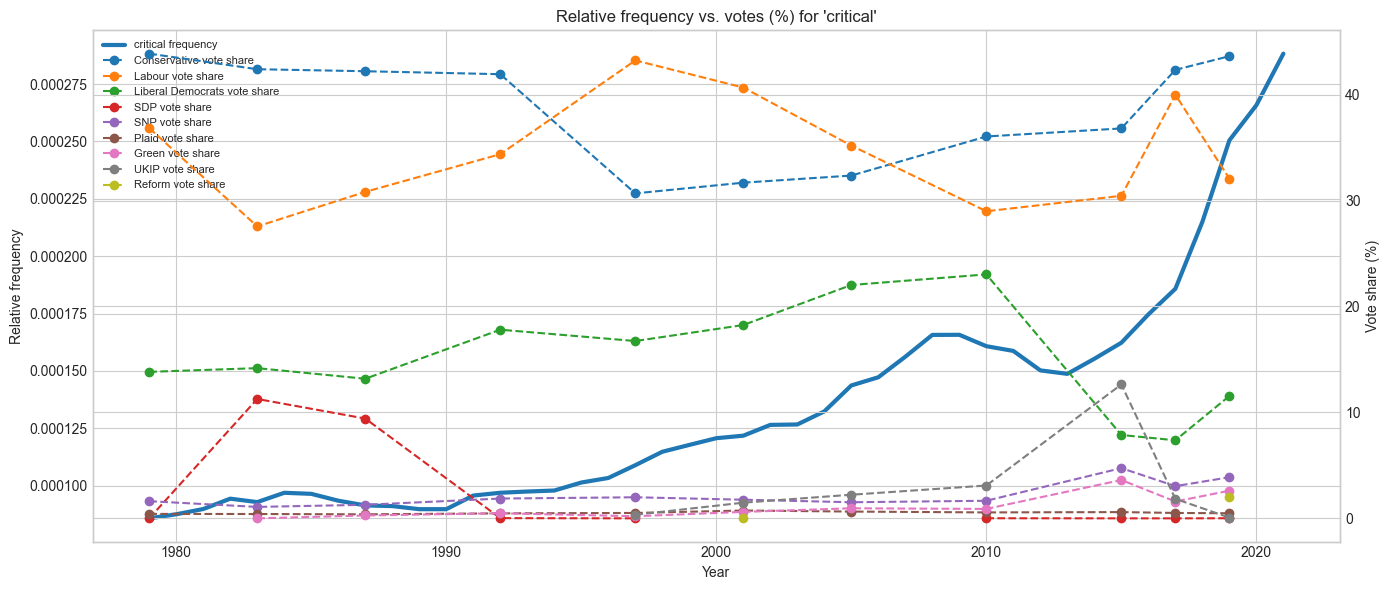

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

votes_path = '/Users/inqfinity/mip/Share of the Vote Won in General Elections 1955-2024.csv'

votes_df = pd.read_csv(votes_path, sep=";", skiprows=[1])

votes_df = votes_df.rename(columns={"electionyear": "year"})
votes_df["year"] = votes_df["year"].astype(int)

votes_df = votes_df[(votes_df["year"] >= 1979) & (votes_df["year"] <= 2021)]

parties_to_plot = [col for col in votes_df.columns if col != "year" and votes_df[col].max() > 0]

for target_word in words_to_find:

    freq_path = f"{output_folder}/{target_word}_relative_freq.csv"
    results_df = pd.read_csv(freq_path)

    fig, ax1 = plt.subplots(figsize=(14, 6))

    ax1.plot(results_df["year"], results_df["smoothed_frequency"], linewidth=3, label=f"{target_word} frequency")

    ax1.set_xlabel("Year")
    ax1.set_ylabel("Relative frequency")

    ax2 = ax1.twinx()

    for party in parties_to_plot:
        ax2.plot(votes_df["year"], votes_df[party], linestyle="--", marker="o", label=f"{party} vote share")

    ax2.set_ylabel("Vote share (%)")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)

    plt.title(f"Relative frequency vs. votes (%) for '{target_word}'")
    plt.tight_layout()
    plt.show()

Again, making it look pretty (asked AI to do it) and this time I asked it to shade in the percentages instead. 

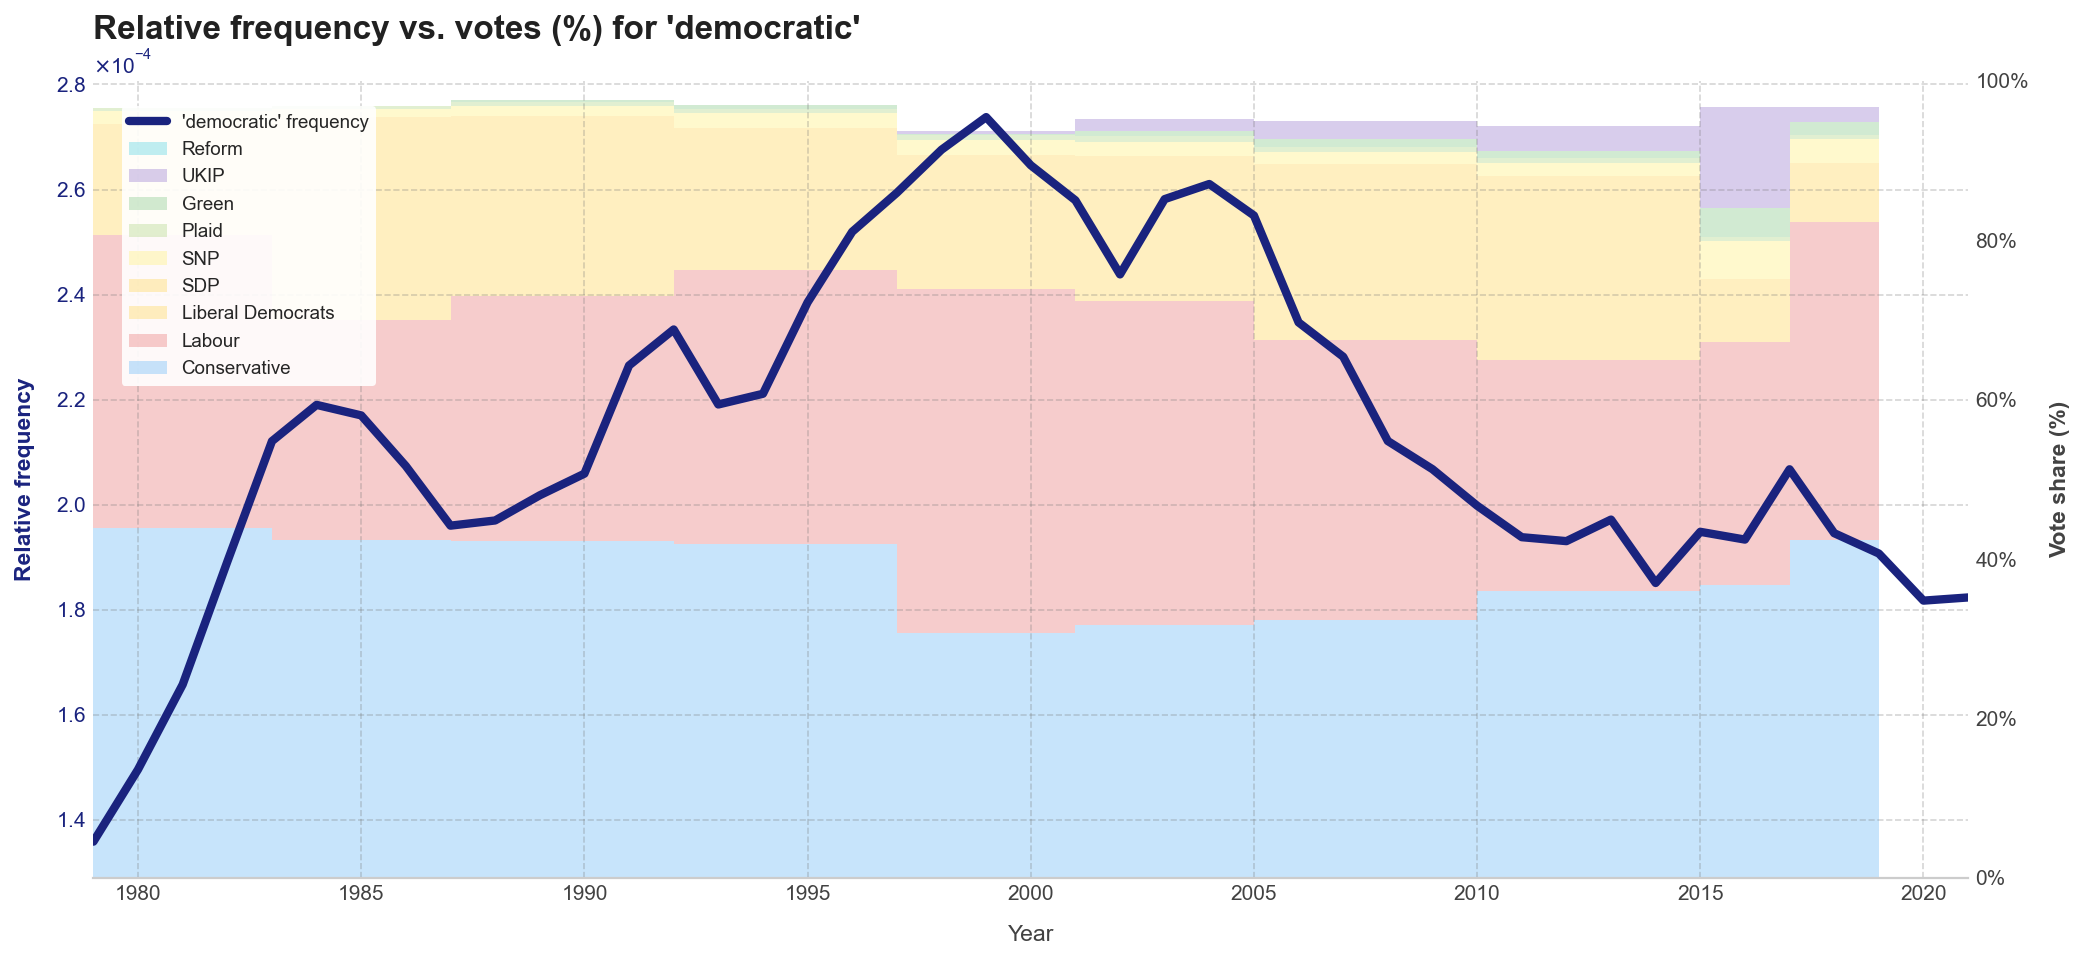

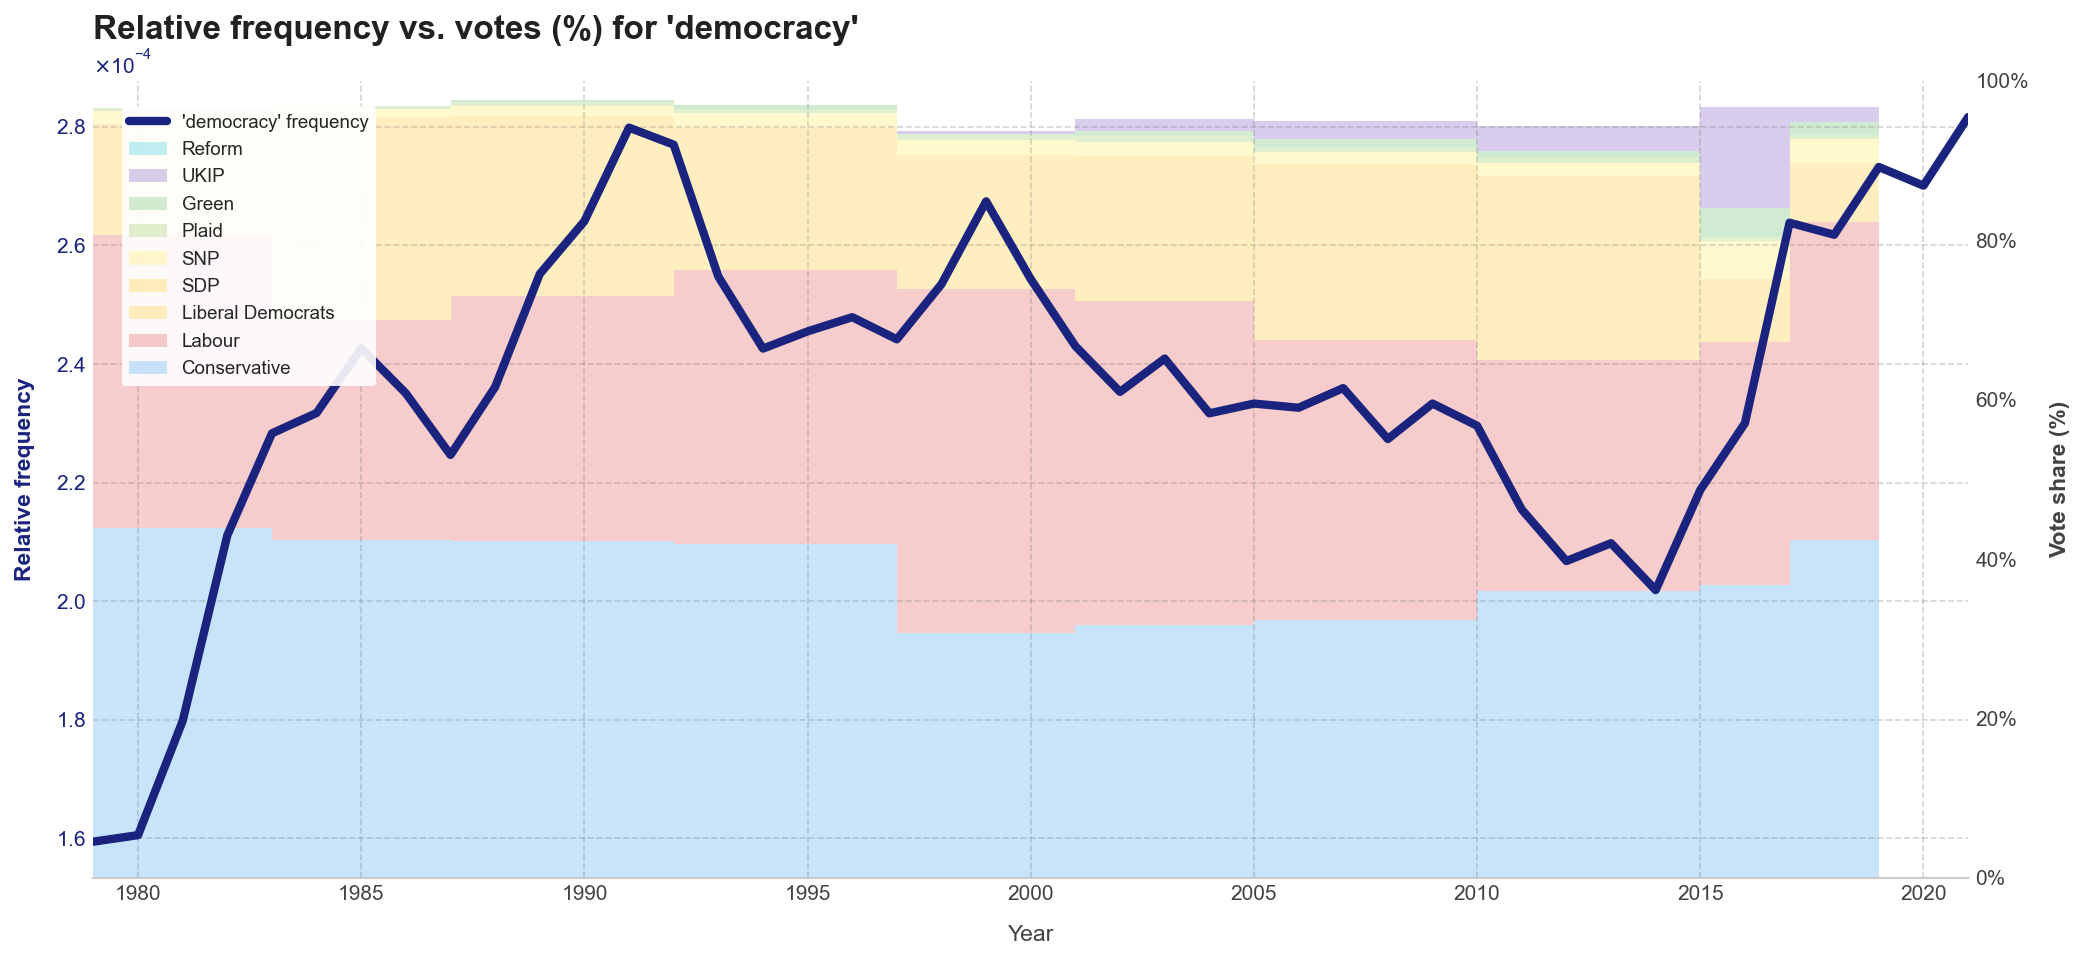

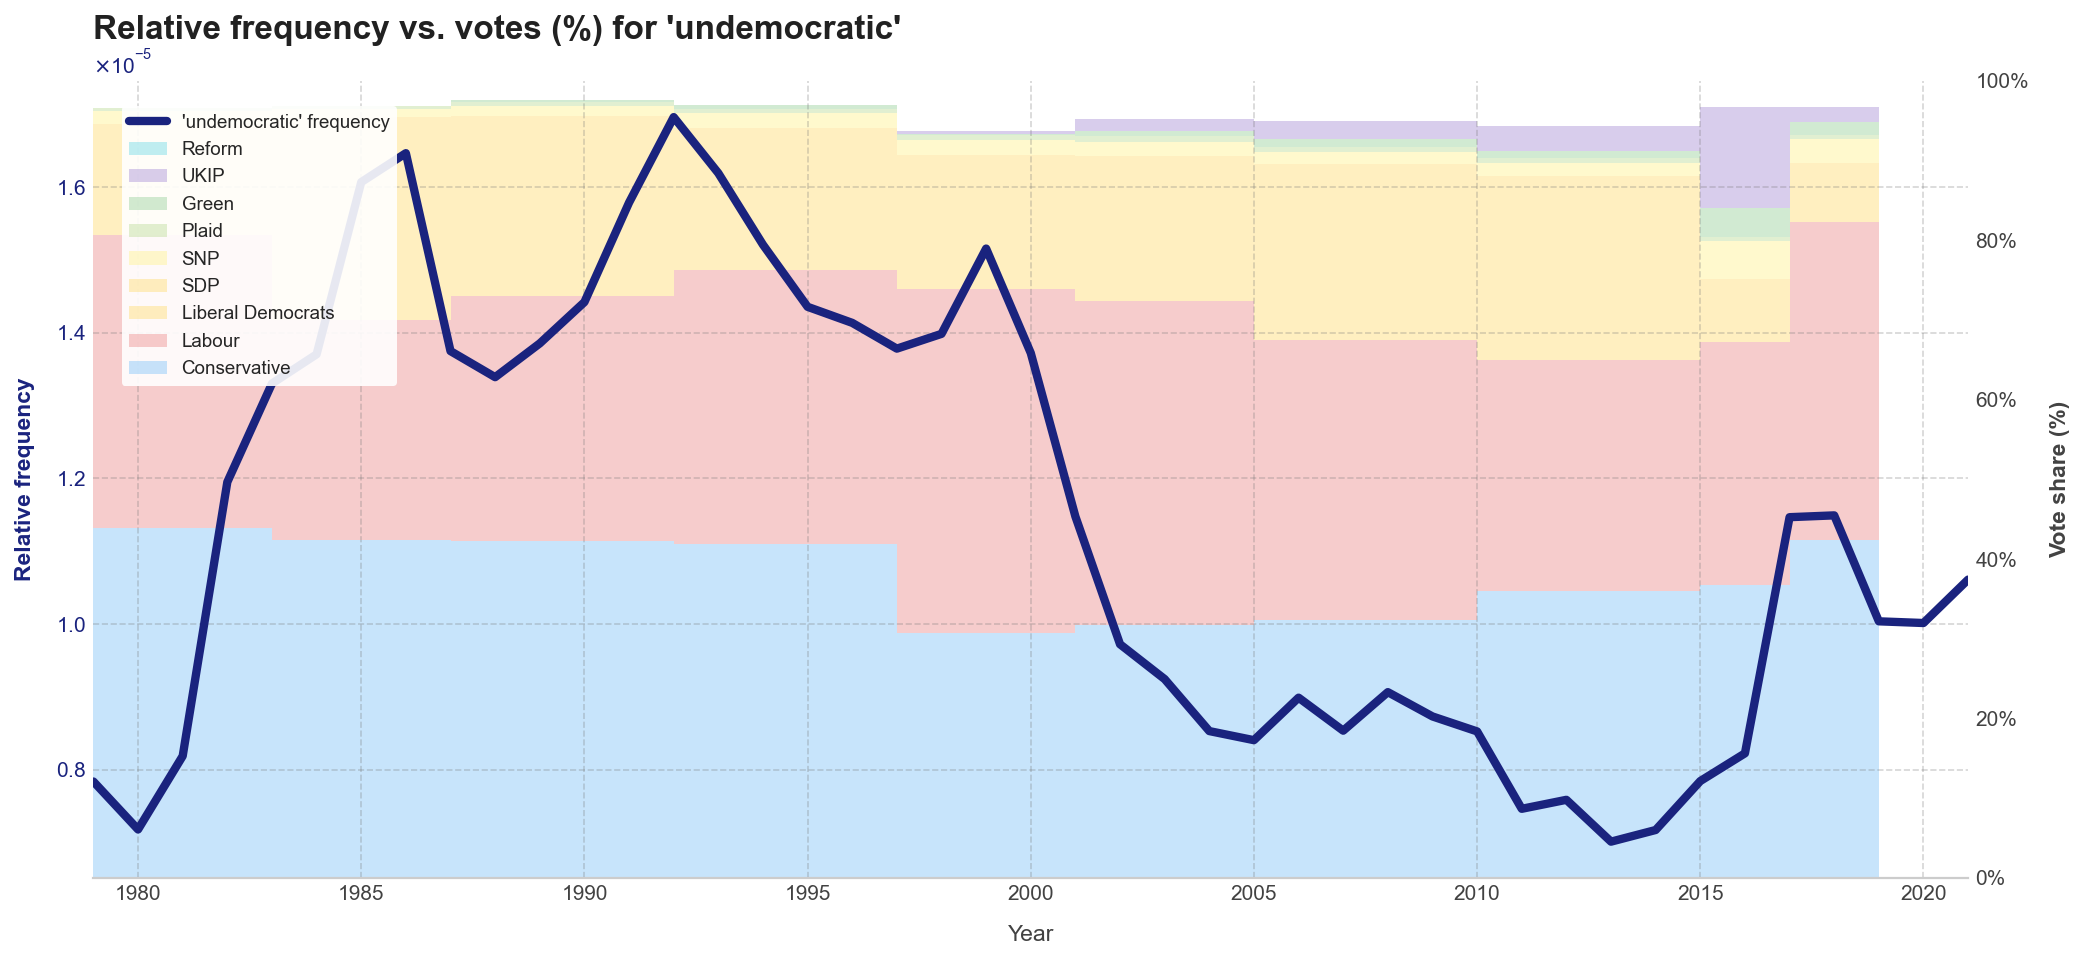

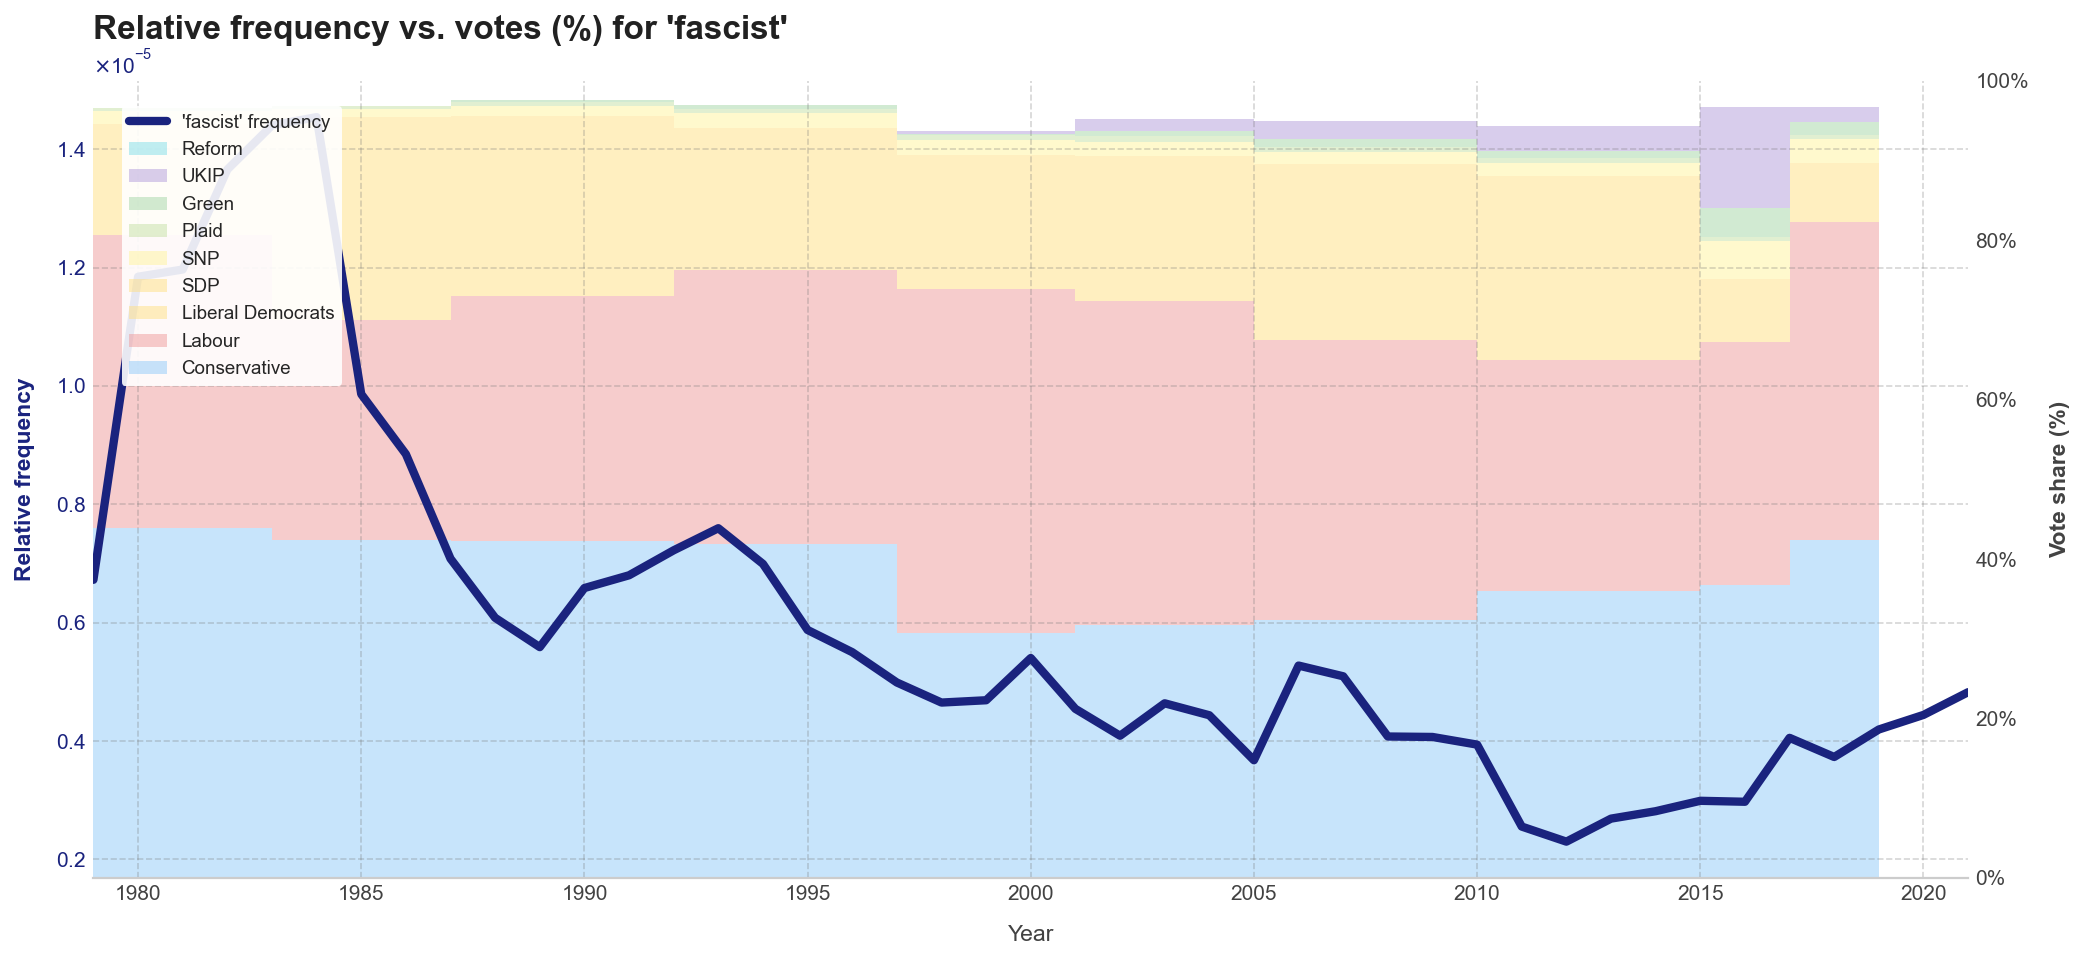

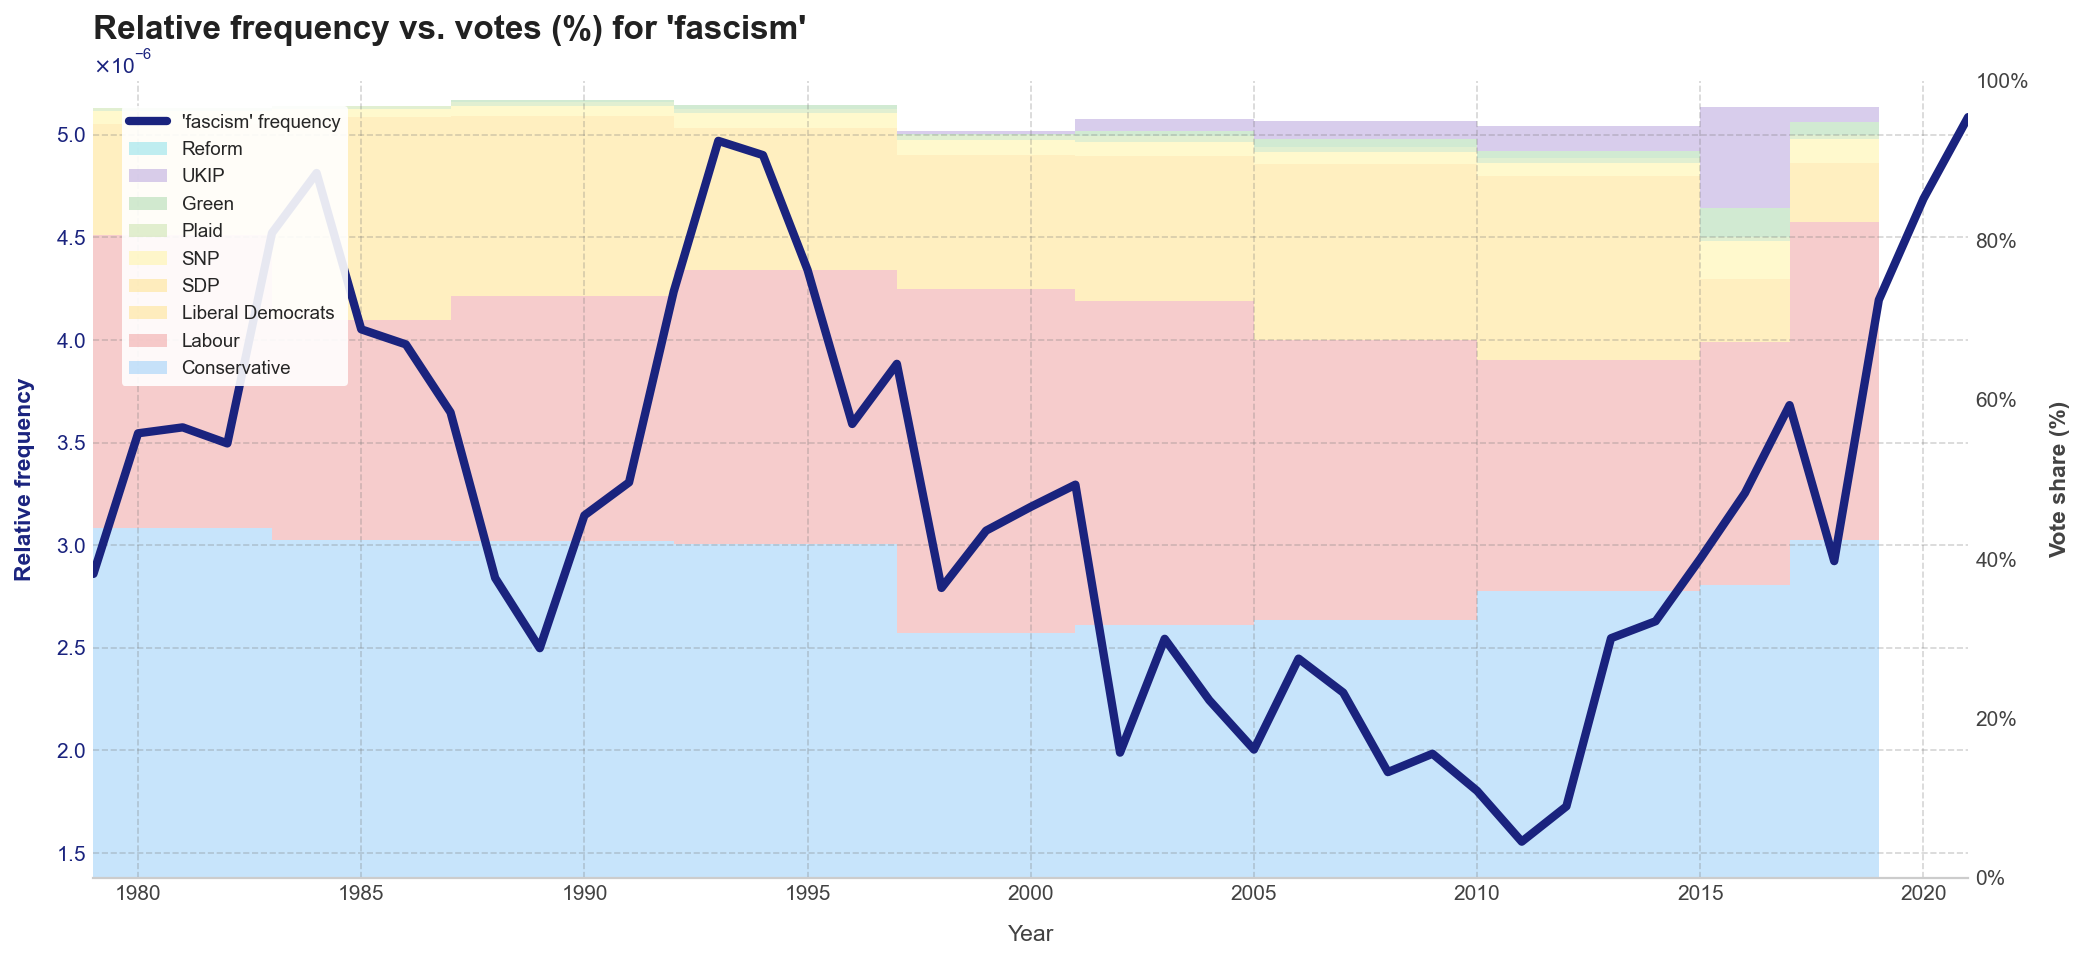

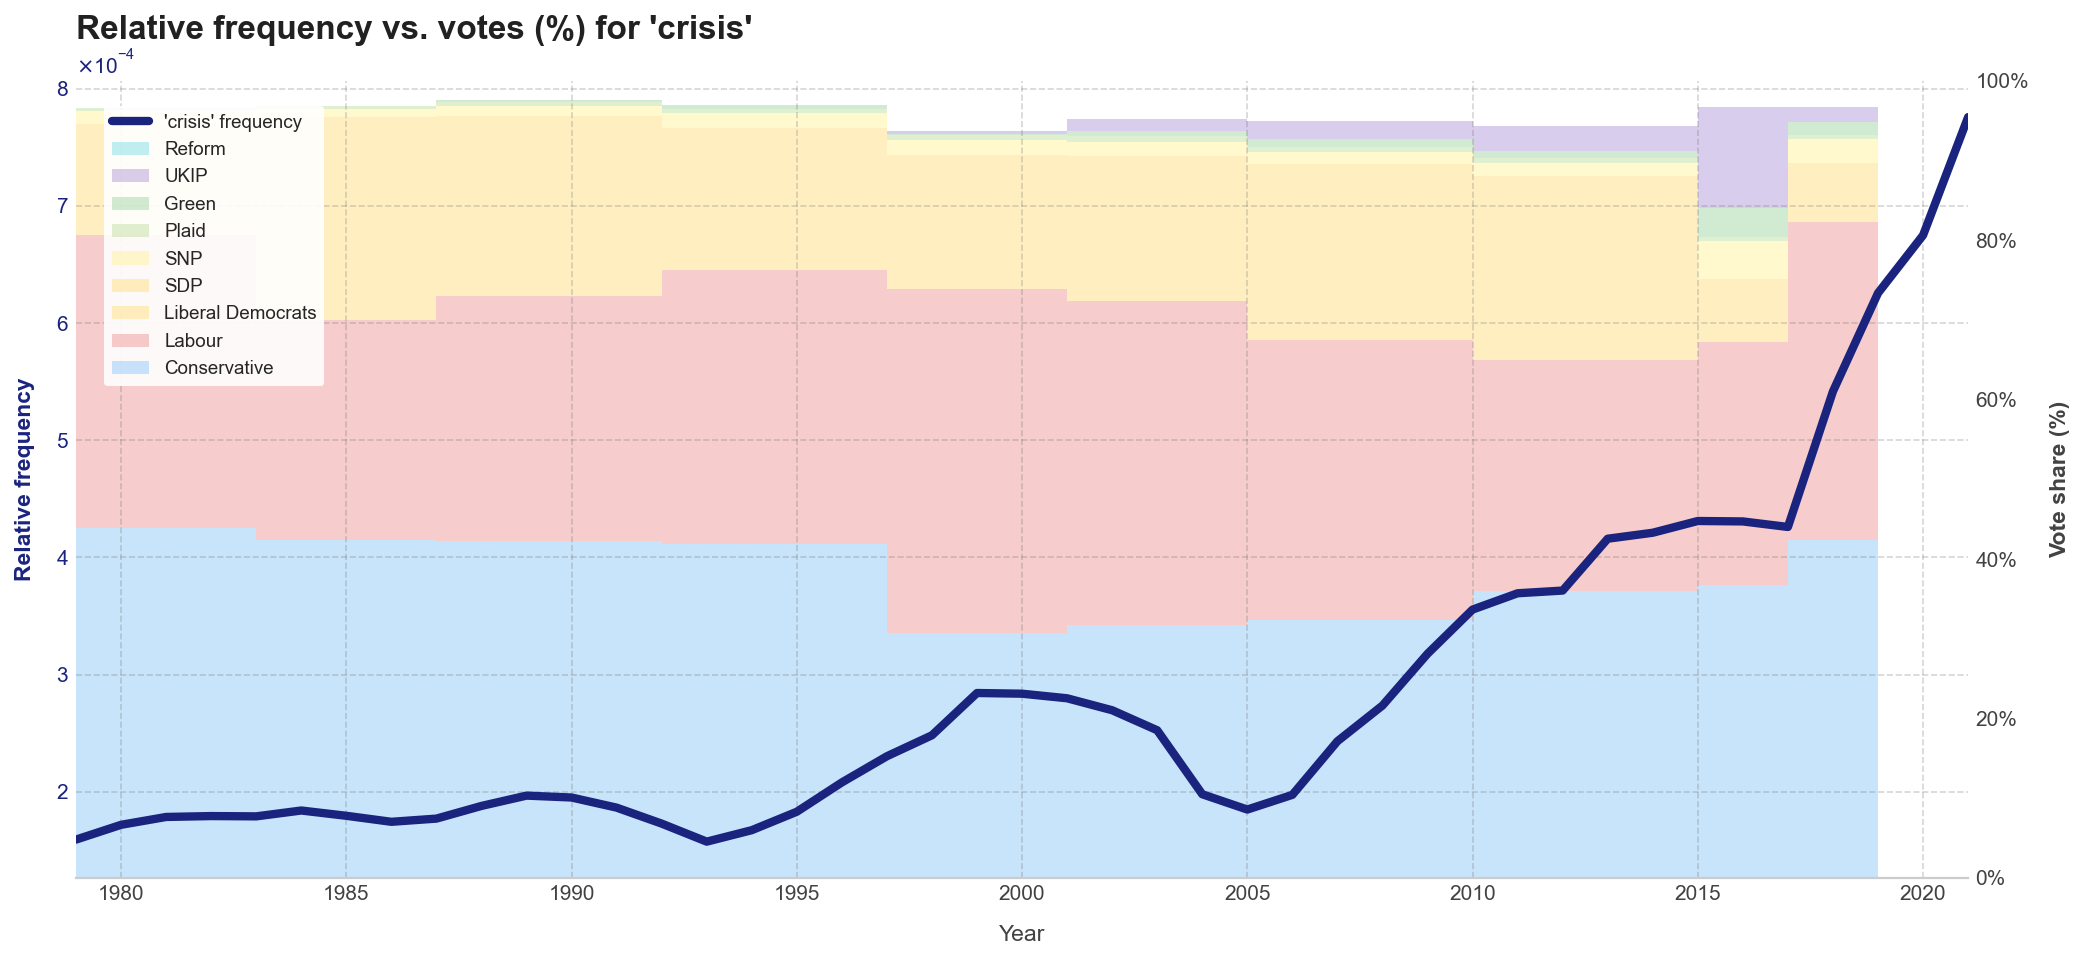

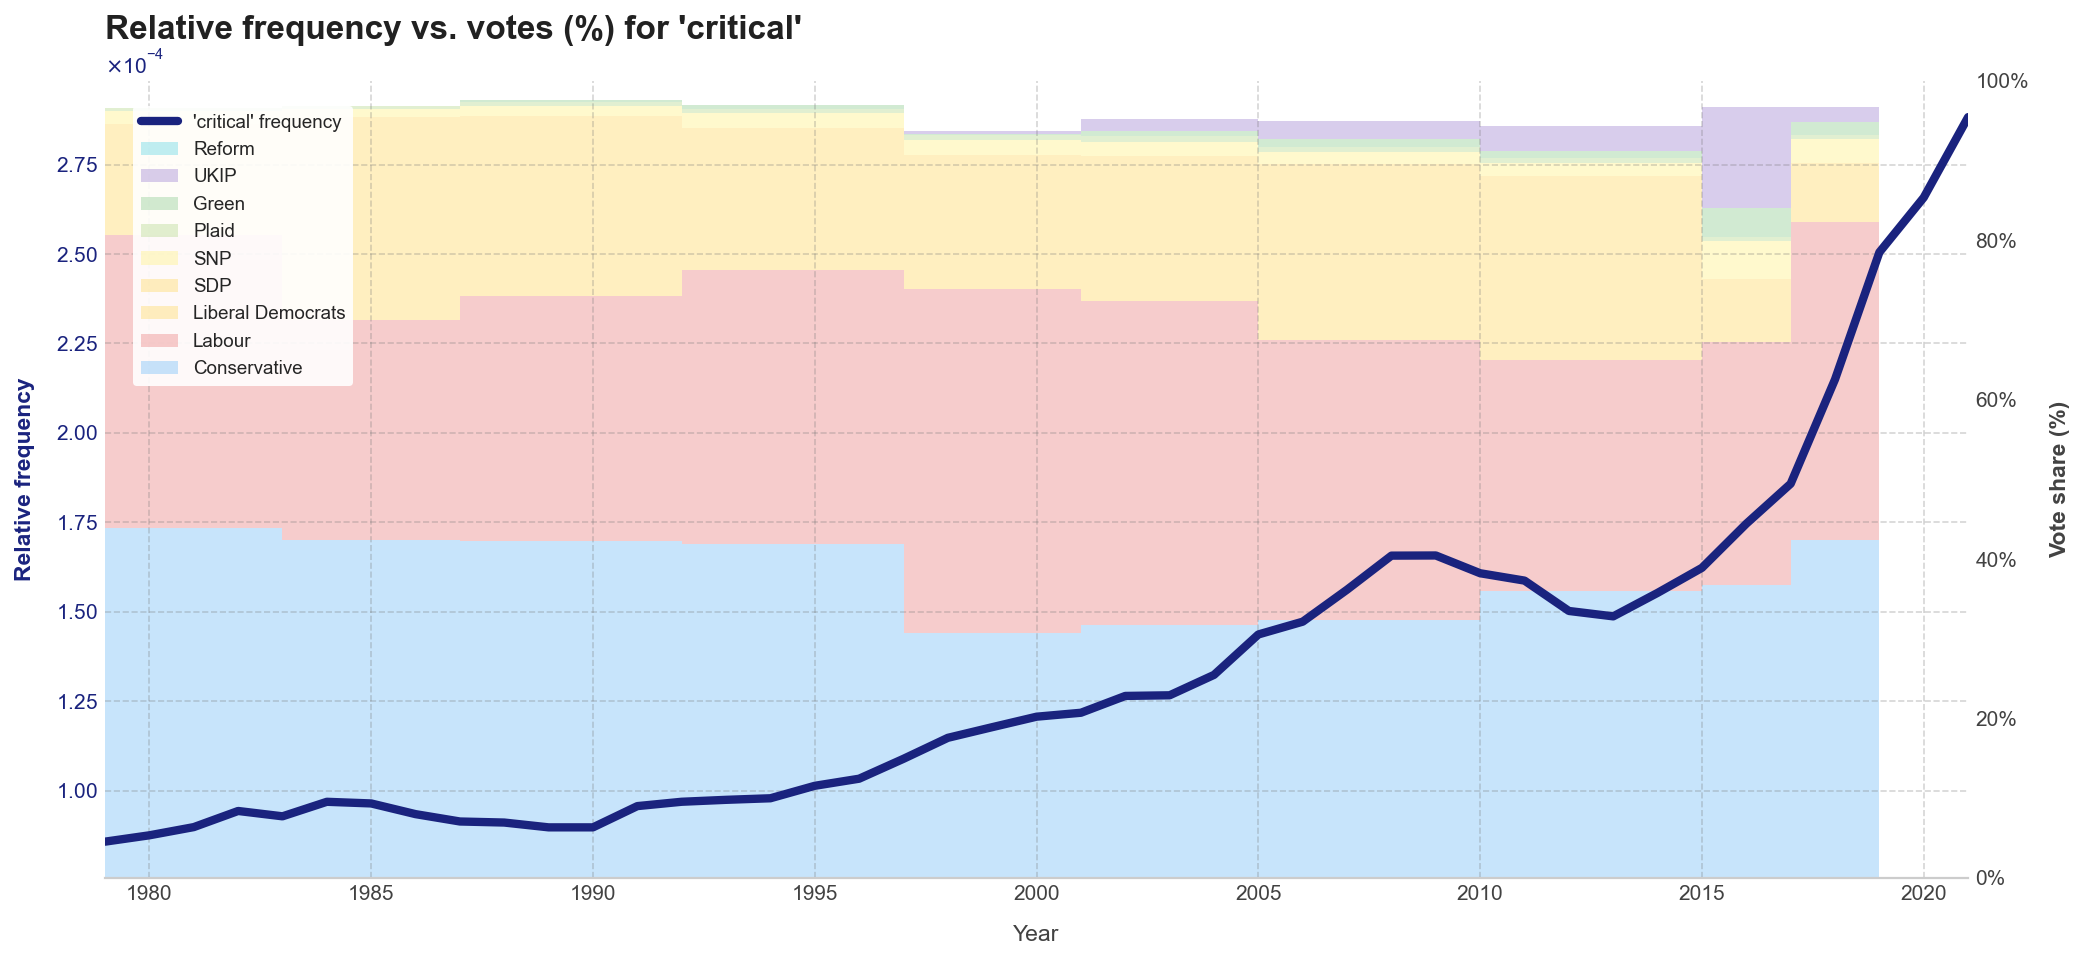

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.style.use("seaborn-v0_8-whitegrid") 

votes_path = '/Users/inqfinity/mip/Share of the Vote Won in General Elections 1955-2024.csv'

votes_df = pd.read_csv(votes_path, sep=";", skiprows=[1])
votes_df = votes_df.rename(columns={"electionyear": "year"})
votes_df["year"] = votes_df["year"].astype(int)
votes_df = votes_df[(votes_df["year"] >= 1979) & (votes_df["year"] <= 2021)].sort_values("year").reset_index(drop=True)

party_cols = [col for col in votes_df.columns if col != "year"]
for col in party_cols:
    votes_df[col] = pd.to_numeric(votes_df[col], errors='coerce').fillna(0)

step_rows = [] #i initially had some issue here so i asked it do basically use stackplot instead (or else matplotlib would "round" and "slope" the shaded regions that give an impression that there is information on years that we dont have data for due to NaN)
for i in range(len(votes_df)):
    current_row = votes_df.iloc[i]
    if i == 0:
   
        step_rows.append(current_row)
    else:
        prev_row = votes_df.iloc[i-1] #make flat line graphs / extend it
        fake_edge_row = current_row.copy()
        for col in party_cols:
            fake_edge_row[col] = prev_row[col]
        step_rows.append(fake_edge_row)
        
        step_rows.append(current_row)


votes_df = pd.DataFrame(step_rows).reset_index(drop=True) #had to ask it to overwrite some stuff

parties_to_plot = [col for col in party_cols if votes_df[col].max() > 0]

political_color_map = {
    "conservative": "#90CAF9",
    "labour": "#EF9A9A",
    "liberal democrats": "#FFE082",
    "sdp": "#FFE082",
    "ukip": "#B39DDB",
    "green": "#A5D6A7",
    "snp": "#FFF59D",
    "plaid": "#C5E1A5",
    "reform": "#80DEEA",
    "other": "#E0E0E0"
}
stack_colors = []
for party in parties_to_plot:
    party_lower = party.lower().strip()
    matched_color = political_color_map.get("other")
    for key, color in political_color_map.items():
        if key in party_lower:
            matched_color = color
            break
    stack_colors.append(matched_color)


for target_word in words_to_find:
    freq_path = f"{output_folder}/{target_word}_relative_freq.csv"
    results_df = pd.read_csv(freq_path)

    fig, ax1 = plt.subplots(figsize=(14, 6.5), dpi=150)

    ax2 = ax1.twinx()

    x_years = votes_df["year"].values
    y_shares = [votes_df[party].values for party in parties_to_plot]

    ax2.stackplot(x_years, y_shares, labels=parties_to_plot, colors=stack_colors, alpha=0.50)

    ax2.set_ylabel("Vote share (%)", fontsize=11, fontweight="bold", color="#424242", labelpad=10)
    ax2.tick_params(axis="y", labelcolor="#424242", labelsize=10)
    ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
    ax2.grid(False) 
    ax2.set_ylim(0, 100)

    line_freq = ax1.plot(
        results_df["year"], results_df["smoothed_frequency"], 
        linewidth=4, color="#1A237E", label=f"'{target_word}' frequency"
    )

    ax1.set_xlabel("Year", fontsize=11, fontweight="medium", color="#424242", labelpad=10)
    ax1.set_ylabel("Relative frequency", fontsize=11, fontweight="bold", color="#1A237E", labelpad=10)
    
    ax1.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    ax1.ticklabel_format(style="sci", axis="y", scilimits=(0,0))
    ax1.tick_params(axis="y", labelcolor="#1A237E", labelsize=10)
    ax1.tick_params(axis="x", labelcolor="#424242", labelsize=10)

    ax1.grid(True, linestyle="--", alpha=0.3, color="#757575")
    ax1.set_zorder(ax2.get_zorder() + 1)
    ax1.patch.set_visible(False) 

    for ax in [ax1, ax2]:
        for spine in ["top", "left", "right"]:
            ax.spines[spine].set_visible(False)

    ax1.set_title(f"Relative frequency vs. votes (%) for '{target_word}'", 
                 fontsize=16, fontweight="bold", pad=20, color="#212121", loc="left")

    handles2, labels2 = ax2.get_legend_handles_labels()
    handles1, labels1 = ax1.get_legend_handles_labels()
    
    ax1.legend(
        handles1 + handles2[::-1], labels1 + labels2[::-1], 
        loc="upper left", bbox_to_anchor=(0.01, 0.98),
        frameon=True, facecolor="white", edgecolor="none", framealpha=0.9, fontsize=9
    )

    ax1.xaxis.set_major_locator(mticker.MultipleLocator(5))
    ax1.set_xlim(1979, 2021)

    plt.tight_layout()
    plt.show()

/var/folders/3c/yddqrddj1j3grpf3ywl6m2y40000gn/T/ipykernel_92165/2647748032.py:83: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  word_colors = cm.get_cmap("tab10", len(words_to_find))


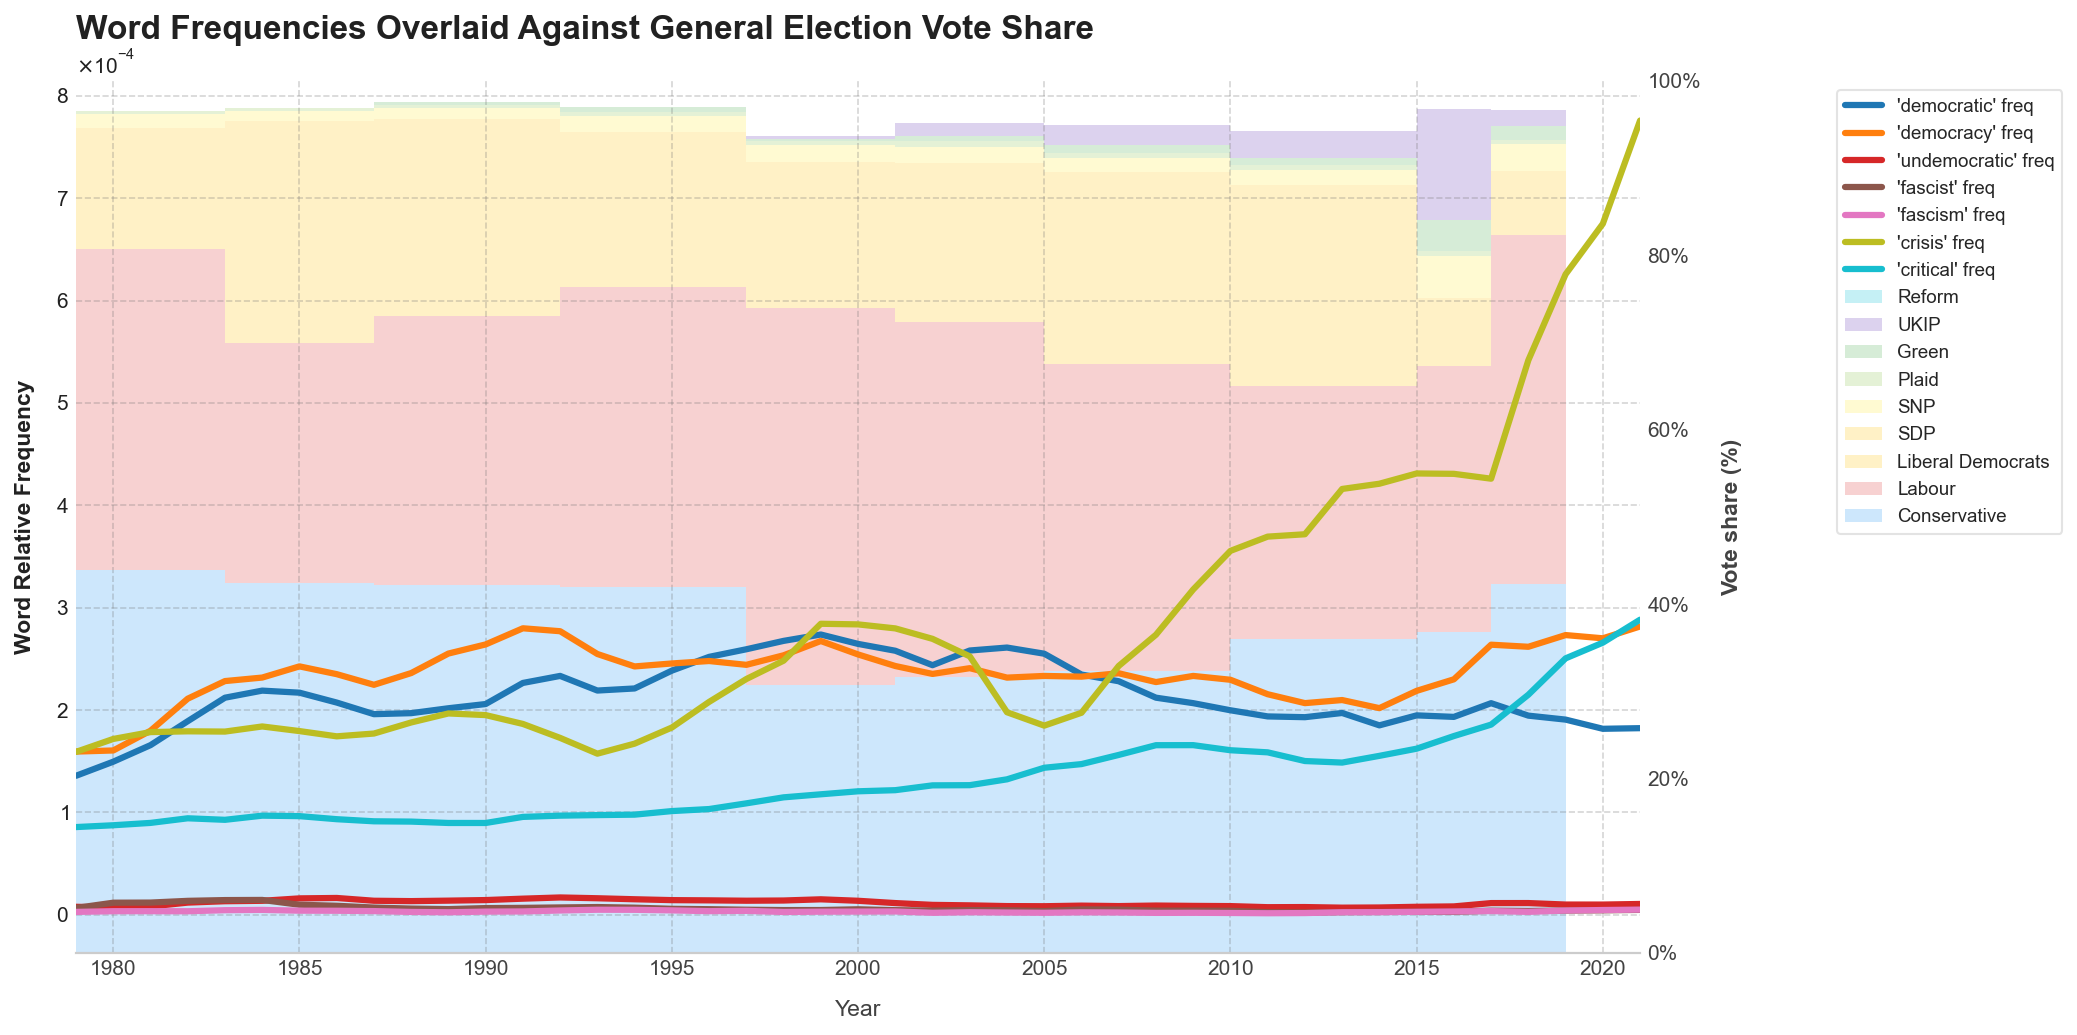

In [25]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

# --- 1. Load and Process Vote Data (Done once) ---
votes_path = (
    "/Users/inqfinity/mip/Share of the Vote Won in General Elections 1955-2024.csv"
)
votes_df = pd.read_csv(votes_path, sep=";", skiprows=[1])
votes_df = votes_df.rename(columns={"electionyear": "year"})
votes_df["year"] = votes_df["year"].astype(int)
votes_df = (
    votes_df[(votes_df["year"] >= 1979) & (votes_df["year"] <= 2021)]
    .sort_values("year")
    .reset_index(drop=True)
)

party_cols = [col for col in votes_df.columns if col != "year"]
for col in party_cols:
    votes_df[col] = pd.to_numeric(votes_df[col], errors="coerce").fillna(0)

# Apply the step-row adjustment to prevent sloped lines between election years
step_rows = []
for i in range(len(votes_df)):
    current_row = votes_df.iloc[i]
    if i == 0:
        step_rows.append(current_row)
    else:
        prev_row = votes_df.iloc[i - 1]
        fake_edge_row = current_row.copy()
        for col in party_cols:
            fake_edge_row[col] = prev_row[col]
        step_rows.append(fake_edge_row)
        step_rows.append(current_row)

votes_df = pd.DataFrame(step_rows).reset_index(drop=True)
parties_to_plot = [col for col in party_cols if votes_df[col].max() > 0]

# Set up party colors
political_color_map = {
    "conservative": "#90CAF9",
    "labour": "#EF9A9A",
    "liberal democrats": "#FFE082",
    "sdp": "#FFE082",
    "ukip": "#B39DDB",
    "green": "#A5D6A7",
    "snp": "#FFF59D",
    "plaid": "#C5E1A5",
    "reform": "#80DEEA",
    "other": "#E0E0E0",
}

stack_colors = []
for party in parties_to_plot:
    party_lower = party.lower().strip()
    matched_color = political_color_map.get("other")
    for key, color in political_color_map.items():
        if key in party_lower:
            matched_color = color
            break
    stack_colors.append(matched_color)


# --- 2. Initialize the Single Shared Canvas ---
fig, ax1 = plt.subplots(figsize=(14, 7), dpi=150)
ax2 = ax1.twinx()  # Secondary axis for the background vote shares

# --- 3. Draw the Vote Share Background (Once) ---
x_years = votes_df["year"].values
y_shares = [votes_df[party].values for party in parties_to_plot]

ax2.stackplot(
    x_years, y_shares, labels=parties_to_plot, colors=stack_colors, alpha=0.45
)

# --- 4. Loop and Overlay All Word Frequencies ---
window_size = 5
# Generate distinct colors for your lines so they don't blend together
word_colors = cm.get_cmap("tab10", len(words_to_find))

for i, target_word in enumerate(words_to_find):
    freq_path = f"{output_folder}/{target_word}_relative_freq.csv"
    results_df = pd.read_csv(freq_path)

    # Use whatever rolling method or column name you already have calculated
    # If "smoothed_frequency" isn't calculated in the CSV yet, uncomment the line below:
    # results_df['smoothed_frequency'] = results_df['relative_freq'].rolling(window=window_size, center=True, min_periods=1).mean()

    ax1.plot(
        results_df["year"],
        results_df["smoothed_frequency"],
        linewidth=3,
        color=word_colors(i),
        label=f"'{target_word}' freq",
    )


# --- 5. Final Formatting and Layout Clean Up ---
# Primary Axis Formatting (Word Frequencies)
ax1.set_xlabel(
    "Year", fontsize=11, fontweight="medium", color="#424242", labelpad=10
)
ax1.set_ylabel(
    "Word Relative Frequency",
    fontsize=11,
    fontweight="bold",
    color="#212121",
    labelpad=10,
)
ax1.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
ax1.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
ax1.tick_params(axis="y", labelcolor="#212121", labelsize=10)
ax1.tick_params(axis="x", labelcolor="#424242", labelsize=10)
ax1.grid(True, linestyle="--", alpha=0.3, color="#757575")

# Secondary Axis Formatting (Vote Share)
ax2.set_ylabel(
    "Vote share (%)",
    fontsize=11,
    fontweight="bold",
    color="#424242",
    labelpad=10,
)
ax2.tick_params(axis="y", labelcolor="#424242", labelsize=10)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax2.grid(False)
ax2.set_ylim(0, 100)

# Crucial layer adjustment: Ensures the lines sit clearly on top of the stackplot fill
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)

# Clean up outer borders smoothly
for ax in [ax1, ax2]:
    for spine in ["top", "left", "right"]:
        ax.spines[spine].set_visible(False)

ax1.set_title(
    "Word Frequencies Overlaid Against General Election Vote Share",
    fontsize=16,
    fontweight="bold",
    pad=20,
    color="#212121",
    loc="left",
)

# Handle limits and intervals
ax1.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax1.set_xlim(1979, 2021)

# Combined Legend Handling
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# We attach it to ax2 and push it further right (1.12 instead of 1.05) 
# to guarantee it clears the right y-axis labels perfectly.
ax2.legend(
    handles1 + handles2[::-1],
    labels1 + labels2[::-1],
    loc="upper left",
    bbox_to_anchor=(1.12, 1),  
    frameon=True,
    facecolor="white",
    edgecolor="#E0E0E0",
    framealpha=0.9,
    fontsize=9,
)

# Tight layout handles padding automatically, but we ensure it accounts for the right edge box
plt.tight_layout()